# Comparing Five Machine Learning Models for Credit Risk Using Home Credit Data

This project uses `application_train.csv` from Kaggle's **Home Credit Default Risk** competition to predict whether an applicant will experience repayment difficulties (`TARGET=1`). It compares five classifiers:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost
5. LightGBM

The notebook runs sequentially from data audit, cleaning, business feature engineering, stratified train/validation/test splitting, training-only feature selection, and five-model tuning through threshold analysis, unified evaluation, probability calibration, risk-decile analysis, and automated English report generation.

## Research Questions

- Which model provides the strongest discrimination by AUC, AR, KS, and PR-AUC?
- How much do complex models improve over Logistic Regression, and is the gain worth the additional interpretation and deployment cost?
- Does a single Decision Tree overfit, and does Random Forest improve stability?
- Are the predicted probabilities reliable, and do Brier Score and Log Loss improve after calibration?
- How many bad applicants are captured in the highest-risk decile, and are the risk bands monotonic?

Because the bad-applicant rate is low, Accuracy can be dominated by the majority class. Model selection therefore focuses on probability ranking, bad-applicant identification, and probability accuracy rather than Accuracy alone.


## 1. Environment and Dependency Check

The following cell prints the major library versions. Missing core dependencies produce a one-time installation hint. SHAP is optional and is not required for the notebook to run successfully.


In [1]:
import gc
import json
import os
import platform
import shutil
import sys
import time
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb
from IPython.display import Markdown, display
from lightgbm import LGBMClassifier
from scipy import sparse
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterSampler,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

versions = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "scikit-learn": sklearn.__version__,
    "xgboost": xgb.__version__,
    "lightgbm": lgb.__version__,
    "joblib": joblib.__version__,
    "nbformat": nbformat.__version__,
}
display(pd.Series(versions, name="version").to_frame())

try:
    import shap  # noqa: F401
    print(f"Optional SHAP dependency installed: {shap.__version__}")
except ImportError:
    print("Optional SHAP dependency is not installed; coefficients and built-in feature importance will be used for interpretation.")
    print("To add SHAP, run separately: %pip install shap")

,version
python,3.13.11
pandas,2.3.3
numpy,2.4.2
matplotlib,3.10.8
scikit-learn,1.8.0
xgboost,2.1.4
lightgbm,4.6.0
joblib,1.5.3
nbformat,5.10.4


Optional SHAP dependency is not installed; coefficients and built-in feature importance will be used for interpretation.
To add SHAP, run separately: %pip install shap


## 2. Central Configuration

The default is a full experiment. For a quick check, set `HOME_CREDIT_DEBUG=1` before launching the notebook. Debug mode reads only the first 40,000 rows and reduces the search space. Full mode uses the entire application table, performs cross-validation tuning on a stratified training subset, and then fits each final model on the complete training set.


In [2]:
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

RANDOM_STATE = 42
TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"
TEST_SIZE = 0.20
VALID_SIZE = 0.20
N_JOBS = -1
SEARCH_N_JOBS = 1

DEBUG_MODE = os.getenv("HOME_CREDIT_DEBUG", "0") == "1"
CLEAN_OUTPUTS = True
DEBUG_READ_ROWS = 40_000
TUNING_SAMPLE_SIZE = 12_000 if DEBUG_MODE else 60_000
CV_FOLDS = 2 if DEBUG_MODE else 5
HIGH_MISSING_THRESHOLD = 0.95
HIGH_CORRELATION_THRESHOLD = 0.98

SEARCH_ITERATIONS = {
    "decision_tree": 3 if DEBUG_MODE else 6,
    "random_forest": 2 if DEBUG_MODE else 4,
    "xgboost": 2 if DEBUG_MODE else 4,
    "lightgbm": 2 if DEBUG_MODE else 4,
}

for path in (OUTPUT_DIR, FIGURE_DIR, MODEL_DIR):
    path.mkdir(parents=True, exist_ok=True)

if CLEAN_OUTPUTS:
    for path in FIGURE_DIR.glob("*.png"):
        path.unlink()
    for path in MODEL_DIR.glob("*.joblib"):
        path.unlink()
    for pattern in ("*.csv", "*.json", "*.md"):
        for path in OUTPUT_DIR.glob(pattern):
            path.unlink()

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.sans-serif": ["Arial Unicode MS", "PingFang SC", "Heiti SC", "DejaVu Sans"],
    "axes.unicode_minus": False,
})

print({
    "DEBUG_MODE": DEBUG_MODE,
    "TUNING_SAMPLE_SIZE": TUNING_SAMPLE_SIZE,
    "CV_FOLDS": CV_FOLDS,
    "DATA_DIR": str(DATA_DIR),
    "OUTPUT_DIR": str(OUTPUT_DIR),
})

{'DEBUG_MODE': False, 'TUNING_SAMPLE_SIZE': 60000, 'CV_FOLDS': 5, 'DATA_DIR': 'data', 'OUTPUT_DIR': 'outputs'}


## 3. Shared Utilities

Shared utilities are defined near the beginning of the notebook and cover safe division, figure saving, stratified sampling, memory conversion, and JSON serialization.


In [3]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    '''Safely divide and convert zero denominators or non-finite results to missing values.'''
    denominator = denominator.replace(0, np.nan)
    result = numerator / denominator
    return result.replace([np.inf, -np.inf], np.nan)


def save_figure(file_name: str, show: bool = False) -> Path:
    '''Apply a tight layout and save the current Matplotlib figure.'''
    path = FIGURE_DIR / file_name
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()
    return path


def stratified_indices(y: pd.Series, max_rows: int, random_state: int = RANDOM_STATE) -> np.ndarray:
    '''Return stratified positional indices with at most max_rows observations.'''
    positions = np.arange(len(y))
    if len(y) <= max_rows:
        return positions
    selected, _ = train_test_split(
        positions,
        train_size=max_rows,
        stratify=np.asarray(y),
        random_state=random_state,
    )
    return np.sort(selected)


def as_float32(matrix):
    '''Convert preprocessed data to float32 while preserving sparse structure.'''
    if sparse.issparse(matrix):
        return matrix.astype(np.float32, copy=False).tocsr()
    return np.asarray(matrix, dtype=np.float32)


def json_safe(value):
    '''Convert NumPy scalars and related objects to JSON-serializable types.'''
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


def slugify_model_name(name: str) -> str:
    '''Generate a stable model filename.'''
    return name.lower().replace(" ", "_").replace("-", "_")

## 4. Data Loading and Initial Audit

The first version uses only the application table to avoid the memory and debugging burden of aggregating several detail tables at once. Kaggle's `application_test.csv` has no public labels, so this project creates training, validation, and final test sets from `application_train.csv`.


In [4]:
data_path = DATA_DIR / "application_train.csv"
if not data_path.exists():
    raise FileNotFoundError(
        f"Could not find {data_path}. Place application_train.csv in the project data/ directory."
    )

read_kwargs = {"low_memory": False}
if DEBUG_MODE:
    read_kwargs["nrows"] = DEBUG_READ_ROWS

load_started = time.perf_counter()
df_raw = pd.read_csv(data_path, **read_kwargs)
load_seconds = time.perf_counter() - load_started

required_columns = {TARGET_COL, ID_COL}
missing_required = required_columns - set(df_raw.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {sorted(missing_required)}")

print(f"Data shape: {df_raw.shape}")
print(f"Load time: {load_seconds:.2f} seconds")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
display(df_raw.head())

Data shape: (307511, 122)
Load time: 2.31 seconds


Memory usage: 504.99 MB


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
target_counts = df_raw[TARGET_COL].value_counts(dropna=False).sort_index()
target_rates = df_raw[TARGET_COL].value_counts(normalize=True, dropna=False).sort_index()
numeric_columns_raw = df_raw.select_dtypes(include=np.number).columns.tolist()
categorical_columns_raw = df_raw.select_dtypes(exclude=np.number).columns.tolist()

basic_checks = {
    "target_missing": int(df_raw[TARGET_COL].isna().sum()),
    "duplicate_customer_ids": int(df_raw[ID_COL].duplicated().sum()),
    "duplicate_rows": int(df_raw.duplicated().sum()),
    "numeric_columns": len(numeric_columns_raw),
    "categorical_columns": len(categorical_columns_raw),
    "all_null_columns": int(df_raw.isna().all().sum()),
    "constant_columns_including_na": int(sum(df_raw[c].nunique(dropna=False) <= 1 for c in df_raw.columns)),
}

numeric_values = df_raw[numeric_columns_raw]
basic_checks["positive_or_negative_infinity"] = int(
    np.isinf(numeric_values.to_numpy(dtype=np.float64, copy=False)).sum()
)

display(pd.Series(basic_checks, name="value").to_frame())
display(pd.DataFrame({"count": target_counts, "rate": target_rates}))

assert basic_checks["target_missing"] == 0, "TARGET contains missing values"
assert set(target_counts.index).issubset({0, 1}), "TARGET is not binary"

,value
target_missing,0
duplicate_customer_ids,0
duplicate_rows,0
numeric_columns,106
categorical_columns,16
all_null_columns,0
constant_columns_including_na,0
positive_or_negative_infinity,0


,count,rate
TARGET,,
0,282686,0.919271
1,24825,0.080729


### 4.1 Class Balance, Missingness, and Outliers

In addition to the target distribution, this section reports the 30 columns with the highest missing rates and applies an IQR diagnostic to numeric outliers. The outlier check is diagnostic only: no imputation or scaling statistics are fitted on the full dataset.


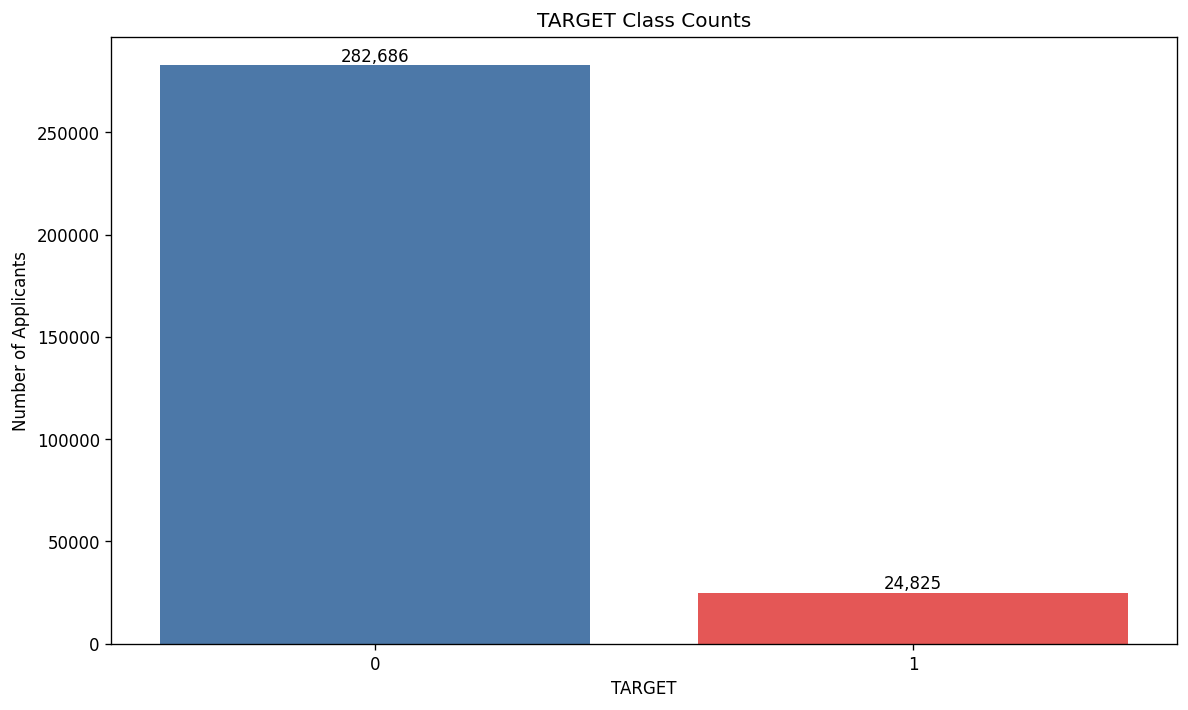

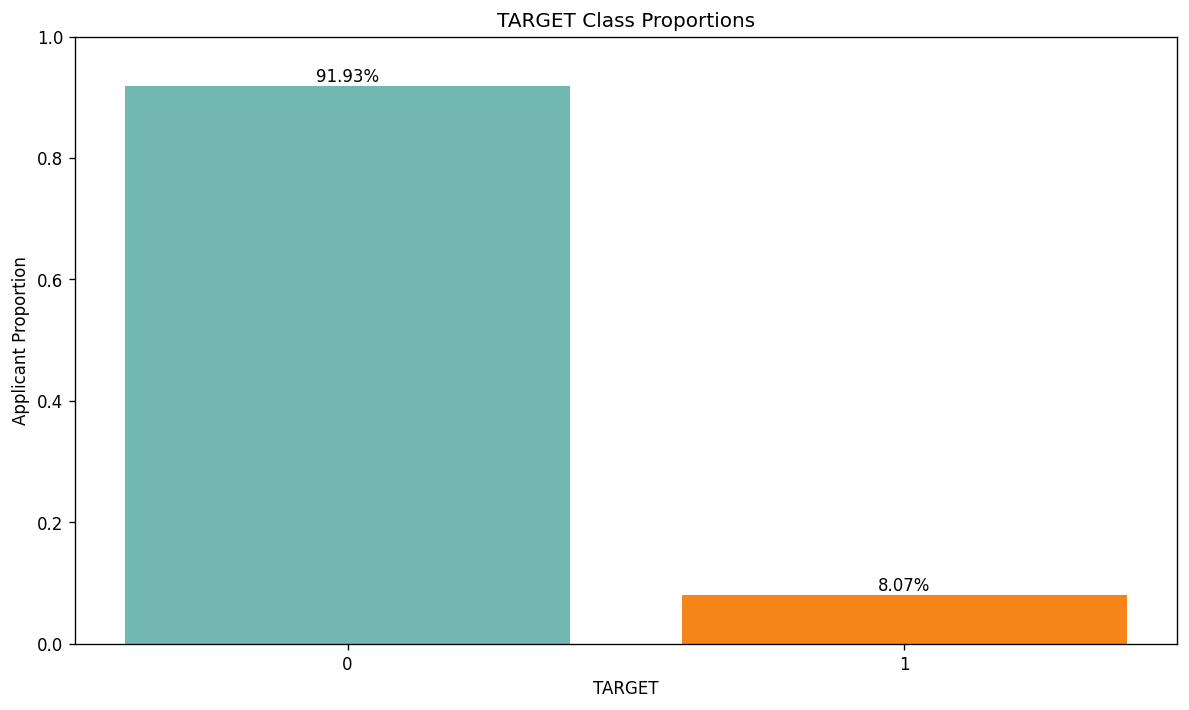

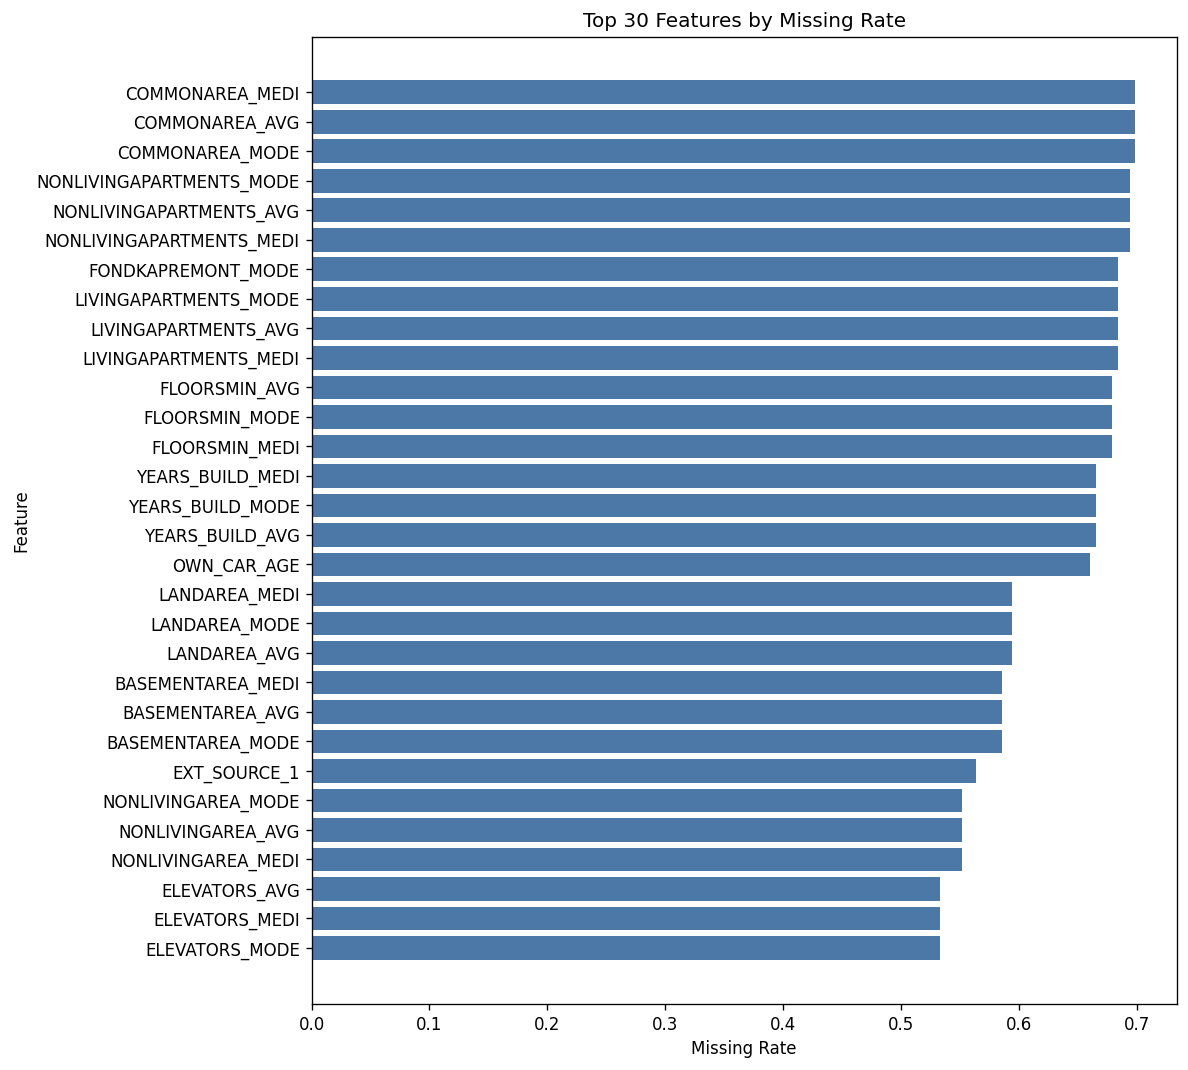

,feature,min,p01,p99,max,extreme_iqr_rate
0,DAYS_EMPLOYED,-17912.0,-10894.9000,365243.000000,365243.0,0.193892
1,NONLIVINGAPARTMENTS_AVG,0.0,0.0000,0.108100,1.0,0.095131
2,NONLIVINGAPARTMENTS_MEDI,0.0,0.0000,0.104800,1.0,0.092769
3,NONLIVINGAPARTMENTS_MODE,0.0,0.0000,0.097300,1.0,0.085716
4,NONLIVINGAREA_MODE,0.0,0.0000,0.322100,1.0,0.082189
5,NONLIVINGAREA_MEDI,0.0,0.0000,0.321272,1.0,0.068121
6,NONLIVINGAREA_AVG,0.0,0.0000,0.316500,1.0,0.062578
7,COMMONAREA_MEDI,0.0,0.0000,0.378555,1.0,0.040800
8,COMMONAREA_MODE,0.0,0.0000,0.365555,1.0,0.040617
9,COMMONAREA_AVG,0.0,0.0000,0.376555,1.0,0.039894


In [6]:
fig, ax = plt.subplots()
ax.bar(target_counts.index.astype(str), target_counts.values, color=["#4C78A8", "#E45756"])
ax.set_title("TARGET Class Counts")
ax.set_xlabel("TARGET")
ax.set_ylabel("Number of Applicants")
for i, value in enumerate(target_counts.values):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")
save_figure("eda_target_count.png", show=True)

fig, ax = plt.subplots()
ax.bar(target_rates.index.astype(str), target_rates.values, color=["#72B7B2", "#F58518"])
ax.set_title("TARGET Class Proportions")
ax.set_xlabel("TARGET")
ax.set_ylabel("Applicant Proportion")
ax.set_ylim(0, 1)
for i, value in enumerate(target_rates.values):
    ax.text(i, value, f"{value:.2%}", ha="center", va="bottom")
save_figure("eda_target_rate.png", show=True)

missing_rates = df_raw.isna().mean().sort_values(ascending=False)
top_missing = missing_rates.head(30).sort_values()
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top_missing.index, top_missing.values, color="#4C78A8")
ax.set_title("Top 30 Features by Missing Rate")
ax.set_xlabel("Missing Rate")
ax.set_ylabel("Feature")
save_figure("eda_top30_missing_rate.png", show=True)

numeric_for_outliers = [
    c for c in numeric_columns_raw
    if c not in {TARGET_COL, ID_COL} and df_raw[c].notna().sum() > 0
]
outlier_rows = []
for column in numeric_for_outliers:
    series = df_raw[column].replace([np.inf, -np.inf], np.nan).dropna()
    if series.empty:
        continue
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 3 * iqr, q3 + 3 * iqr
    outlier_rate = ((series < lower) | (series > upper)).mean() if iqr > 0 else 0.0
    outlier_rows.append({
        "feature": column,
        "min": series.min(),
        "p01": series.quantile(0.01),
        "p99": series.quantile(0.99),
        "max": series.max(),
        "extreme_iqr_rate": outlier_rate,
    })

outlier_summary = (
    pd.DataFrame(outlier_rows)
    .sort_values("extreme_iqr_rate", ascending=False)
    .reset_index(drop=True)
)
display(outlier_summary.head(20))

## 5. Data Cleaning

- Replace the Home Credit sentinel `DAYS_EMPLOYED=365243` with missing values.
- Replace positive and negative infinity with missing values.
- Remove entirely missing and single-value columns.
- Retain the applicant identifier only for traceability and exclude it before modeling.
- Fit medians, modes, and encoding mappings later inside training-only pipelines.


In [7]:
df_clean = df_raw.copy()
cleaning_log = []

if "DAYS_EMPLOYED" in df_clean.columns:
    anomaly_count = int((df_clean["DAYS_EMPLOYED"] == 365243).sum())
    df_clean["DAYS_EMPLOYED"] = df_clean["DAYS_EMPLOYED"].replace(365243, np.nan)
    cleaning_log.append({"action": "replace_days_employed_365243", "affected": anomaly_count})

numeric_cols = df_clean.select_dtypes(include=np.number).columns
infinity_count = int(np.isinf(df_clean[numeric_cols].to_numpy(dtype=np.float64, copy=False)).sum())
df_clean[numeric_cols] = df_clean[numeric_cols].replace([np.inf, -np.inf], np.nan)
cleaning_log.append({"action": "replace_infinity", "affected": infinity_count})

all_null_columns = [c for c in df_clean.columns if df_clean[c].isna().all()]
constant_columns = [
    c for c in df_clean.columns
    if c not in {TARGET_COL, ID_COL} and df_clean[c].nunique(dropna=False) <= 1
]
pre_split_drop_columns = sorted(set(all_null_columns + constant_columns))
df_clean = df_clean.drop(columns=pre_split_drop_columns)
cleaning_log.append({"action": "drop_all_null_or_constant", "affected": len(pre_split_drop_columns)})

display(pd.DataFrame(cleaning_log))
display(pd.DataFrame({"dropped_column": pre_split_drop_columns}))

assert TARGET_COL in df_clean.columns
assert ID_COL in df_clean.columns
assert not np.isinf(df_clean.select_dtypes(include=np.number).to_numpy()).any()

,action,affected
0,replace_days_employed_365243,55374
1,replace_infinity,0
2,drop_all_null_or_constant,0


,dropped_column


## 6. Business Feature Engineering

Only a small set of interpretable ratios is created: credit burden, annuity burden, approximate term, goods-price coverage, employment stability, income per household member, and payment rate. Every division handles zero denominators and non-finite results.


In [8]:
feature_formulas = {
    "CREDIT_INCOME_RATIO": ("AMT_CREDIT", "AMT_INCOME_TOTAL", "Credit relative to income; overall debt burden"),
    "ANNUITY_INCOME_RATIO": ("AMT_ANNUITY", "AMT_INCOME_TOTAL", "Annuity relative to income; repayment pressure"),
    "CREDIT_ANNUITY_RATIO": ("AMT_CREDIT", "AMT_ANNUITY", "Credit-to-annuity ratio; approximate repayment term"),
    "GOODS_CREDIT_RATIO": ("AMT_GOODS_PRICE", "AMT_CREDIT", "Goods price relative to credit amount"),
    "EMPLOYED_BIRTH_RATIO": ("DAYS_EMPLOYED", "DAYS_BIRTH", "Employment duration relative to age; employment stability"),
    "INCOME_PER_PERSON": ("AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS", "Income per household member"),
    "PAYMENT_RATE": ("AMT_ANNUITY", "AMT_CREDIT", "Annuity-to-credit ratio; periodic payment burden"),
}

engineered_features = []
feature_explanations = []
for new_feature, (numerator, denominator, explanation) in feature_formulas.items():
    if numerator in df_clean.columns and denominator in df_clean.columns:
        df_clean[new_feature] = safe_divide(df_clean[numerator], df_clean[denominator])
        engineered_features.append(new_feature)
        feature_explanations.append({"feature": new_feature, "business_meaning": explanation})

df_clean[engineered_features] = df_clean[engineered_features].replace([np.inf, -np.inf], np.nan)
display(pd.DataFrame(feature_explanations))
print(f"Engineered business features: {len(engineered_features)}")

/var/folders/2v/__1b87yj6l9d7xgv06crr1hr0000gn/T/ipykernel_14675/867907171.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[new_feature] = safe_divide(df_clean[numerator], df_clean[denominator])
/var/folders/2v/__1b87yj6l9d7xgv06crr1hr0000gn/T/ipykernel_14675/867907171.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean[new_feature] = safe_divide(df_clean[numerator], df_clean[denominator])
/var/folders/2v/__1b87yj6l9d7xgv06crr1hr0000gn/T/ipykernel_14675/867907171.py:15: PerformanceWarning: DataFrame is hig

,feature,business_meaning
0,CREDIT_INCOME_RATIO,Credit relative to income; overall debt burden
1,ANNUITY_INCOME_RATIO,Annuity relative to income; repayment pressure
2,CREDIT_ANNUITY_RATIO,Credit-to-annuity ratio; approximate repayment term
3,GOODS_CREDIT_RATIO,Goods price relative to credit amount
4,EMPLOYED_BIRTH_RATIO,Employment duration relative to age; employment stability
5,INCOME_PER_PERSON,Income per household member
6,PAYMENT_RATE,Annuity-to-credit ratio; periodic payment burden


Engineered business features: 7


## 7. Train, Validation, and Test Split

The data is split 60%/20%/20% with stratification. The validation set is used for early stopping, threshold selection, and calibration selection. The test set is used only once all modeling choices have been fixed.


In [9]:
X = df_clean.drop(columns=[TARGET_COL, ID_COL])
y = df_clean[TARGET_COL].astype(np.int8)
customer_ids = df_clean[ID_COL].copy()

X_train, X_temp, y_train, y_temp, id_train, id_temp = train_test_split(
    X,
    y,
    customer_ids,
    test_size=TEST_SIZE + VALID_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)
relative_test_size = TEST_SIZE / (TEST_SIZE + VALID_SIZE)
X_valid, X_test, y_valid, y_test, id_valid, id_test = train_test_split(
    X_temp,
    y_temp,
    id_temp,
    test_size=relative_test_size,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame([
    {"split": "train", "rows": len(y_train), "bad_count": int(y_train.sum()), "bad_rate": y_train.mean()},
    {"split": "validation", "rows": len(y_valid), "bad_count": int(y_valid.sum()), "bad_rate": y_valid.mean()},
    {"split": "test", "rows": len(y_test), "bad_count": int(y_test.sum()), "bad_rate": y_test.mean()},
])
display(split_summary)

assert set(X_train.columns) == set(X_valid.columns) == set(X_test.columns)
assert max(split_summary["bad_rate"]) - min(split_summary["bad_rate"]) < 0.002

del X_temp, y_temp, id_temp
gc.collect()

,split,rows,bad_count,bad_rate
0,train,184506,14895,0.080729
1,validation,61502,4965,0.080729
2,test,61503,4965,0.080728


2500

## 8. Training-Only Feature Selection

Only the training set is used to decide which columns to remove:

1. More than 95% missing in the training set.
2. No variation in the training set.
3. For numeric pairs with absolute correlation above 0.98, keep the earlier column and remove the later one.

This demonstrates feature-selection logic without using validation or test statistics.


In [10]:
train_missing_rates = X_train.isna().mean()
high_missing_columns = train_missing_rates[train_missing_rates > HIGH_MISSING_THRESHOLD].index.tolist()
train_constant_columns = [c for c in X_train.columns if X_train[c].nunique(dropna=False) <= 1]

numeric_train_columns = X_train.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = X_train[numeric_train_columns].corr().abs()
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)
high_correlation_columns = [
    column for column in upper_triangle.columns
    if (upper_triangle[column] > HIGH_CORRELATION_THRESHOLD).any()
]

selection_drop_columns = sorted(set(
    high_missing_columns + train_constant_columns + high_correlation_columns
))
selected_columns = [c for c in X_train.columns if c not in selection_drop_columns]

X_train = X_train[selected_columns].copy()
X_valid = X_valid[selected_columns].copy()
X_test = X_test[selected_columns].copy()

selection_summary = pd.DataFrame([
    {"rule": "missing_rate_gt_threshold", "threshold": HIGH_MISSING_THRESHOLD, "dropped": len(high_missing_columns)},
    {"rule": "constant_in_training", "threshold": np.nan, "dropped": len(train_constant_columns)},
    {"rule": "absolute_correlation_gt_threshold", "threshold": HIGH_CORRELATION_THRESHOLD, "dropped": len(high_correlation_columns)},
    {"rule": "total_unique_dropped", "threshold": np.nan, "dropped": len(selection_drop_columns)},
])
display(selection_summary)
display(pd.DataFrame({"dropped_feature": selection_drop_columns}).head(50))
print(f"Features before selection: {X.shape[1]}; features after selection: {len(selected_columns)}")

pd.DataFrame({"selected_feature": selected_columns}).to_csv(
    OUTPUT_DIR / "selected_features.csv", index=False
)
pd.DataFrame({"dropped_feature": selection_drop_columns}).to_csv(
    OUTPUT_DIR / "dropped_features.csv", index=False
)

,rule,threshold,dropped
0,missing_rate_gt_threshold,0.95,0
1,constant_in_training,NaN,0
2,absolute_correlation_gt_threshold,0.98,19
3,total_unique_dropped,NaN,19


,dropped_feature
0,AMT_GOODS_PRICE
1,APARTMENTS_MEDI
2,BASEMENTAREA_MEDI
3,COMMONAREA_MEDI
4,ELEVATORS_MEDI
5,ENTRANCES_MEDI
6,FLOORSMAX_MEDI
7,FLOORSMAX_MODE
8,FLOORSMIN_MEDI
9,FLOORSMIN_MODE


Features before selection: 127; features after selection: 108


## 9. Leakage-Safe Preprocessing Pipelines

Separate preprocessors are built for Logistic Regression and tree models. Both are fitted only on the training set:

- Numeric features: median imputation; Logistic Regression also receives scaling.
- Categorical features: mode imputation and sparse One-Hot Encoding; unknown categories are ignored.
- Validation and test sets call `transform` only.


In [11]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_lr_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])
numeric_tree_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=True,
        dtype=np.float32,
    )),
])

logistic_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_lr_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=False,
)
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_tree_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    sparse_threshold=1.0,
    verbose_feature_names_out=False,
)

transform_started = time.perf_counter()
X_train_logistic = as_float32(logistic_preprocessor.fit_transform(X_train))
X_valid_logistic = as_float32(logistic_preprocessor.transform(X_valid))
X_test_logistic = as_float32(logistic_preprocessor.transform(X_test))

X_train_tree = as_float32(tree_preprocessor.fit_transform(X_train))
X_valid_tree = as_float32(tree_preprocessor.transform(X_valid))
X_test_tree = as_float32(tree_preprocessor.transform(X_test))
transform_seconds = time.perf_counter() - transform_started

logistic_feature_names = np.asarray(logistic_preprocessor.get_feature_names_out())
tree_feature_names = np.asarray(tree_preprocessor.get_feature_names_out())

joblib.dump(logistic_preprocessor, MODEL_DIR / "logistic_preprocessor.joblib")
joblib.dump(tree_preprocessor, MODEL_DIR / "tree_preprocessor.joblib")

encoded_summary = pd.DataFrame([
    {"pipeline": "logistic", "train_shape": str(X_train_logistic.shape), "sparse": sparse.issparse(X_train_logistic)},
    {"pipeline": "tree", "train_shape": str(X_train_tree.shape), "sparse": sparse.issparse(X_train_tree)},
])
display(encoded_summary)
print(f"Total preprocessing time: {transform_seconds:.2f} seconds")

assert TARGET_COL not in logistic_feature_names
assert ID_COL not in logistic_feature_names
assert X_train_logistic.shape[1] == X_valid_logistic.shape[1] == X_test_logistic.shape[1]
assert X_train_tree.shape[1] == X_valid_tree.shape[1] == X_test_tree.shape[1]
assert X_train_tree.shape[1] < 5_000, "Unexpected One-Hot feature explosion"

,pipeline,train_shape,sparse
0,logistic,"(184506, 232)",True
1,tree,"(184506, 232)",True


Total preprocessing time: 3.59 seconds


## 10. Unified Evaluation, Threshold, and Tuning Functions

AUC, AR, KS, and PR-AUC are always calculated from predicted probabilities. Thresholds are selected on the validation set only; the final test set is not used to choose models, parameters, thresholds, or calibration methods.


In [12]:
def select_thresholds(y_true, y_prob, recall_targets=(0.70, 0.80)) -> dict[str, float]:
    '''Calculate maximum-F1, maximum-Youden, and target-recall thresholds from validation probabilities.'''
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)
    if len(pr_thresholds) == 0:
        raise ValueError("Cannot select a threshold from a single unique predicted probability")
    denominator = precision[:-1] + recall[:-1]
    f1_values = np.divide(
        2 * precision[:-1] * recall[:-1],
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > 0,
    )
    max_f1_threshold = float(pr_thresholds[int(np.nanargmax(f1_values))])

    fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
    finite_mask = np.isfinite(roc_thresholds)
    youden_values = tpr[finite_mask] - fpr[finite_mask]
    youden_threshold = float(roc_thresholds[finite_mask][int(np.argmax(youden_values))])

    thresholds = {
        "default_0.5": 0.5,
        "max_f1": max_f1_threshold,
        "max_youden": youden_threshold,
    }
    for target in recall_targets:
        valid = np.where(recall[:-1] >= target)[0]
        if len(valid):
            best_position = valid[int(np.argmax(precision[:-1][valid]))]
            thresholds[f"target_recall_{int(target * 100)}"] = float(pr_thresholds[best_position])
    return thresholds


def evaluate_model(model_name, y_true, y_prob, threshold=0.5) -> dict[str, float]:
    '''Calculate unified probability and classification metrics for binary credit risk.'''
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(y_true) != len(y_prob):
        raise ValueError("y_true and y_prob have different lengths")
    if not np.isfinite(y_prob).all():
        raise ValueError(f"{model_name} contains NaN or infinite predicted probabilities")

    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    ks = float(np.max(tpr - fpr))
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    metrics = {
        "Model": model_name,
        "Threshold": float(threshold),
        "AUC": float(auc),
        "AR": float(2 * auc - 1),
        "KS": ks,
        "PR-AUC": float(average_precision_score(y_true, y_prob)),
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "Specificity": float(specificity),
        "Brier": float(brier_score_loss(y_true, y_prob)),
        "LogLoss": float(log_loss(y_true, np.clip(y_prob, 1e-7, 1 - 1e-7))),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "PassRate": float((y_pred == 0).mean()),
        "RejectRate": float((y_pred == 1).mean()),
        "BadCaptureRate": float(tp / (tp + fn)) if (tp + fn) else np.nan,
    }

    assert 0 <= metrics["AUC"] <= 1
    assert -1 <= metrics["AR"] <= 1
    assert 0 <= metrics["KS"] <= 1
    assert 0 <= metrics["PR-AUC"] <= 1
    return metrics


def threshold_operating_table(model_name, y_true, y_prob, thresholds) -> pd.DataFrame:
    '''Return operating metrics for multiple thresholds of the same model.'''
    rows = []
    for threshold_name, threshold in thresholds.items():
        metrics = evaluate_model(model_name, y_true, y_prob, threshold)
        rows.append({
            "Model": model_name,
            "ThresholdName": threshold_name,
            "Threshold": threshold,
            "Precision": metrics["Precision"],
            "Recall": metrics["Recall"],
            "F1": metrics["F1"],
            "Specificity": metrics["Specificity"],
            "PassRate": metrics["PassRate"],
            "RejectRate": metrics["RejectRate"],
            "BadCaptureRate": metrics["BadCaptureRate"],
        })
    return pd.DataFrame(rows)


def positive_probability(model, matrix) -> np.ndarray:
    '''Return predicted probabilities for the positive class.'''
    probability = model.predict_proba(matrix)[:, 1]
    return np.asarray(probability, dtype=float)

In [13]:
cv_strategy = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

tuning_positions = stratified_indices(y_train, TUNING_SAMPLE_SIZE)
X_tune_logistic = X_train_logistic[tuning_positions]
X_tune_tree = X_train_tree[tuning_positions]
y_tune = y_train.iloc[tuning_positions].to_numpy()

print({
    "tuning_rows": len(y_tune),
    "tuning_bad_count": int(y_tune.sum()),
    "tuning_bad_rate": float(y_tune.mean()),
    "cv_folds": CV_FOLDS,
})

{'tuning_rows': 60000, 'tuning_bad_count': 4844, 'tuning_bad_rate': 0.08073333333333334, 'cv_folds': 5}


In [14]:
def tune_sklearn_model(
    estimator,
    parameter_space,
    X_tune,
    y_tune,
    X_full,
    y_full,
    search_kind="random",
    n_iter=None,
):
    '''Search parameters on a tuning subset, then fit the final model on the full training set.'''
    if search_kind == "grid":
        search = GridSearchCV(
            estimator=estimator,
            param_grid=parameter_space,
            scoring="roc_auc",
            cv=cv_strategy,
            n_jobs=SEARCH_N_JOBS,
            refit=True,
            error_score="raise",
            return_train_score=True,
        )
    else:
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=parameter_space,
            n_iter=n_iter,
            scoring="roc_auc",
            cv=cv_strategy,
            n_jobs=SEARCH_N_JOBS,
            refit=True,
            random_state=RANDOM_STATE,
            error_score="raise",
            return_train_score=True,
        )

    tuning_started = time.perf_counter()
    search.fit(X_tune, y_tune)
    tuning_seconds = time.perf_counter() - tuning_started

    final_model = clone(estimator).set_params(**search.best_params_)
    training_started = time.perf_counter()
    final_model.fit(X_full, np.asarray(y_full))
    training_seconds = time.perf_counter() - training_started

    return final_model, {
        "best_params": json_safe(search.best_params_),
        "best_search_auc": float(search.best_score_),
        "tuning_seconds": tuning_seconds,
        "training_seconds": training_seconds,
        "candidate_count": len(search.cv_results_["params"]),
    }


def tune_xgboost(X_train_matrix, y_train_values, X_valid_matrix, y_valid_values):
    '''Manually search XGBoost parameters with validation-based early stopping.'''
    negative_count = int((np.asarray(y_train_values) == 0).sum())
    positive_count = int((np.asarray(y_train_values) == 1).sum())
    scale_pos_weight = negative_count / positive_count
    parameter_space = {
        "learning_rate": [0.025, 0.05, 0.08],
        "max_depth": [3, 4, 5],
        "min_child_weight": [5, 15, 30],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.65, 0.8, 1.0],
        "reg_alpha": [0.0, 0.1, 0.5],
        "reg_lambda": [1.0, 5.0, 10.0],
        "gamma": [0.0, 0.1, 0.3],
    }
    candidates = list(ParameterSampler(
        parameter_space,
        n_iter=SEARCH_ITERATIONS["xgboost"],
        random_state=RANDOM_STATE,
    ))

    best_model = None
    best_params = None
    best_auc = -np.inf
    best_fit_seconds = np.nan
    tuning_started = time.perf_counter()
    candidate_rows = []
    for candidate_number, params in enumerate(candidates, start=1):
        model = xgb.XGBClassifier(
            n_estimators=250 if DEBUG_MODE else 1_200,
            objective="binary:logistic",
            eval_metric="auc",
            tree_method="hist",
            max_bin=255,
            scale_pos_weight=scale_pos_weight,
            early_stopping_rounds=25 if DEBUG_MODE else 60,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            **params,
        )
        fit_started = time.perf_counter()
        model.fit(
            X_train_matrix,
            np.asarray(y_train_values),
            eval_set=[(X_valid_matrix, np.asarray(y_valid_values))],
            verbose=False,
        )
        fit_seconds = time.perf_counter() - fit_started
        valid_probability = positive_probability(model, X_valid_matrix)
        valid_auc = roc_auc_score(y_valid_values, valid_probability)
        best_iteration = int(getattr(model, "best_iteration", model.n_estimators - 1))
        candidate_rows.append({
            "candidate": candidate_number,
            "validation_auc": valid_auc,
            "best_iteration": best_iteration,
            "fit_seconds": fit_seconds,
            "params": json.dumps(json_safe(params), ensure_ascii=False, sort_keys=True),
        })
        if valid_auc > best_auc:
            best_auc = valid_auc
            best_model = model
            best_params = params | {"best_iteration": best_iteration}
            best_fit_seconds = fit_seconds

    return best_model, {
        "best_params": json_safe(best_params),
        "best_search_auc": float(best_auc),
        "tuning_seconds": time.perf_counter() - tuning_started,
        "training_seconds": best_fit_seconds,
        "candidate_count": len(candidates),
        "candidate_results": pd.DataFrame(candidate_rows),
    }


def tune_lightgbm(X_train_matrix, y_train_values, X_valid_matrix, y_valid_values):
    '''Manually search LightGBM parameters with validation-based early stopping.'''
    negative_count = int((np.asarray(y_train_values) == 0).sum())
    positive_count = int((np.asarray(y_train_values) == 1).sum())
    scale_pos_weight = negative_count / positive_count
    parameter_space = {
        "learning_rate": [0.02, 0.04, 0.06],
        "num_leaves": [15, 31, 63],
        "max_depth": [-1, 5, 7],
        "min_child_samples": [30, 80, 150],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.65, 0.8, 1.0],
        "reg_alpha": [0.0, 0.1, 0.5],
        "reg_lambda": [0.0, 1.0, 5.0],
    }
    candidates = list(ParameterSampler(
        parameter_space,
        n_iter=SEARCH_ITERATIONS["lightgbm"],
        random_state=RANDOM_STATE,
    ))

    best_model = None
    best_params = None
    best_auc = -np.inf
    best_fit_seconds = np.nan
    tuning_started = time.perf_counter()
    candidate_rows = []
    for candidate_number, params in enumerate(candidates, start=1):
        model = LGBMClassifier(
            n_estimators=300 if DEBUG_MODE else 1_500,
            objective="binary",
            metric="auc",
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbosity=-1,
            **params,
        )
        fit_started = time.perf_counter()
        model.fit(
            X_train_matrix,
            np.asarray(y_train_values),
            eval_set=[(X_valid_matrix, np.asarray(y_valid_values))],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(25 if DEBUG_MODE else 60, verbose=False)],
        )
        fit_seconds = time.perf_counter() - fit_started
        valid_probability = positive_probability(model, X_valid_matrix)
        valid_auc = roc_auc_score(y_valid_values, valid_probability)
        best_iteration = int(getattr(model, "best_iteration_", model.n_estimators))
        candidate_rows.append({
            "candidate": candidate_number,
            "validation_auc": valid_auc,
            "best_iteration": best_iteration,
            "fit_seconds": fit_seconds,
            "params": json.dumps(json_safe(params), ensure_ascii=False, sort_keys=True),
        })
        if valid_auc > best_auc:
            best_auc = valid_auc
            best_model = model
            best_params = params | {"best_iteration": best_iteration}
            best_fit_seconds = fit_seconds

    return best_model, {
        "best_params": json_safe(best_params),
        "best_search_auc": float(best_auc),
        "tuning_seconds": time.perf_counter() - tuning_started,
        "training_seconds": best_fit_seconds,
        "candidate_count": len(candidates),
        "candidate_results": pd.DataFrame(candidate_rows),
    }

## 11. Training and Tuning Five Models

Logistic Regression uses GridSearchCV. Decision Tree and Random Forest use RandomizedSearchCV. XGBoost and LightGBM use staged random candidates with validation-set early stopping. ROC-AUC is the primary tuning metric throughout.


### 11.1 Logistic Regression

Logistic Regression provides an interpretable credit-scoring baseline. The `saga` solver supports both L1 and L2 penalties and is better suited to large sparse One-Hot matrices while avoiding invalid solver/penalty combinations.


In [15]:
models = {}
training_info = {}

logistic_base = LogisticRegression(
    class_weight="balanced",
    max_iter=1_000 if DEBUG_MODE else 2_000,
    solver="saga",
    tol=1e-3,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
)
logistic_grid = {
    "C": [0.1, 1.0] if DEBUG_MODE else [0.01, 0.1, 1.0],
    "penalty": ["l1", "l2"],
    "class_weight": ["balanced"],
}
models["Logistic Regression"], training_info["Logistic Regression"] = tune_sklearn_model(
    logistic_base,
    logistic_grid,
    X_tune_logistic,
    y_tune,
    X_train_logistic,
    y_train,
    search_kind="grid",
)
print(training_info["Logistic Regression"])

{'best_params': {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1'}, 'best_search_auc': 0.7413765681686754, 'tuning_seconds': 187.95972658297978, 'training_seconds': 23.54743791697547, 'candidate_count': 6}


### 11.2 Decision Tree

A single tree is used to examine nonlinear relationships and feature interactions. Depth, leaf size, and pruning parameters control overfitting.


In [16]:
decision_tree_base = DecisionTreeClassifier(random_state=RANDOM_STATE)
decision_tree_space = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [4, 6, 8, 12, None],
    "min_samples_split": [10, 50, 200],
    "min_samples_leaf": [20, 100, 500],
    "max_features": [None, "sqrt", 0.7],
    "class_weight": [None, "balanced"],
    "ccp_alpha": [0.0, 1e-5, 1e-4],
}
models["Decision Tree"], training_info["Decision Tree"] = tune_sklearn_model(
    decision_tree_base,
    decision_tree_space,
    X_tune_tree,
    y_tune,
    X_train_tree,
    y_train,
    search_kind="random",
    n_iter=SEARCH_ITERATIONS["decision_tree"],
)
tree_model = models["Decision Tree"]
training_info["Decision Tree"]["tree_depth"] = int(tree_model.get_depth())
training_info["Decision Tree"]["leaf_count"] = int(tree_model.get_n_leaves())
print(training_info["Decision Tree"])

{'best_params': {'min_samples_split': 50, 'min_samples_leaf': 500, 'max_features': 0.7, 'max_depth': 8, 'criterion': 'gini', 'class_weight': 'balanced', 'ccp_alpha': 1e-05}, 'best_search_auc': 0.7054121990348997, 'tuning_seconds': 9.12503687501885, 'training_seconds': 2.3345062079606578, 'candidate_count': 6, 'tree_depth': 8, 'leaf_count': 142}


### 11.3 Random Forest

Random Forest uses bagging to reduce the variance of a single tree. Tree depth and leaf size are constrained to control model size, and the OOB score is retained as an additional diagnostic.


In [17]:
random_forest_base = RandomForestClassifier(
    class_weight="balanced_subsample",
    bootstrap=True,
    oob_score=True,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
)
random_forest_space = {
    "n_estimators": [120, 180] if DEBUG_MODE else [180, 250, 320],
    "max_depth": [8, 12, 16],
    "min_samples_split": [10, 50, 150],
    "min_samples_leaf": [5, 20, 50],
    "max_features": ["sqrt", 0.5],
    "class_weight": ["balanced", "balanced_subsample"],
}
models["Random Forest"], training_info["Random Forest"] = tune_sklearn_model(
    random_forest_base,
    random_forest_space,
    X_tune_tree,
    y_tune,
    X_train_tree,
    y_train,
    search_kind="random",
    n_iter=SEARCH_ITERATIONS["random_forest"],
)
training_info["Random Forest"]["oob_score"] = float(models["Random Forest"].oob_score_)
print(training_info["Random Forest"])

{'best_params': {'n_estimators': 180, 'min_samples_split': 150, 'min_samples_leaf': 50, 'max_features': 'sqrt', 'max_depth': 16, 'class_weight': 'balanced'}, 'best_search_auc': 0.738602947910681, 'tuning_seconds': 399.8119276249781, 'training_seconds': 40.303729541017674, 'candidate_count': 4, 'oob_score': 0.7678612077656011}


### 11.4 XGBoost

`scale_pos_weight` is set from the class ratio, and validation AUC controls early stopping. The best iteration is saved in the parameter table.


In [18]:
models["XGBoost"], training_info["XGBoost"] = tune_xgboost(
    X_train_tree,
    y_train,
    X_valid_tree,
    y_valid,
)
display(training_info["XGBoost"]["candidate_results"])

,candidate,validation_auc,best_iteration,fit_seconds,params
0,1,0.763680,1194,1107.171455,"{""colsample_bytree"": 0.65, ""gamma"": 0.1, ""lear..."
1,2,0.762576,672,682.125426,"{""colsample_bytree"": 1.0, ""gamma"": 0.1, ""learn..."
2,3,0.765105,1197,1138.041727,"{""colsample_bytree"": 1.0, ""gamma"": 0.1, ""learn..."
3,4,0.764105,1172,1150.481297,"{""colsample_bytree"": 1.0, ""gamma"": 0.1, ""learn..."


### 11.5 LightGBM

The leaf-wise gradient boosting model is regularized through `num_leaves`, `max_depth`, minimum leaf size, and penalty terms, with validation-based early stopping.


In [19]:
models["LightGBM"], training_info["LightGBM"] = tune_lightgbm(
    X_train_tree,
    y_train,
    X_valid_tree,
    y_valid,
)
display(training_info["LightGBM"]["candidate_results"])

assert set(models) == {
    "Logistic Regression", "Decision Tree", "Random Forest", "XGBoost", "LightGBM"
}

,candidate,validation_auc,best_iteration,fit_seconds,params
0,1,0.765284,298,4.529769,"{""colsample_bytree"": 0.65, ""learning_rate"": 0...."
1,2,0.761987,564,5.732677,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0..."
2,3,0.764231,283,4.240243,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0..."
3,4,0.764511,625,5.458715,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0..."


## 12. Model Diagnostics and Unified Test Evaluation

This section checks train/validation AUC gaps, probability validity, and threshold performance. Each model first selects a threshold on validation data and then applies that threshold to the test set once.


In [20]:
matrix_sets = {
    "Logistic Regression": (X_train_logistic, X_valid_logistic, X_test_logistic),
    "Decision Tree": (X_train_tree, X_valid_tree, X_test_tree),
    "Random Forest": (X_train_tree, X_valid_tree, X_test_tree),
    "XGBoost": (X_train_tree, X_valid_tree, X_test_tree),
    "LightGBM": (X_train_tree, X_valid_tree, X_test_tree),
}

probabilities = {}
threshold_tables = []
selected_metric_rows = []
default_metric_rows = []
overfit_rows = []
best_parameter_rows = []

for model_name, model in models.items():
    train_matrix, valid_matrix, test_matrix = matrix_sets[model_name]

    train_probability = positive_probability(model, train_matrix)
    valid_probability = positive_probability(model, valid_matrix)
    prediction_started = time.perf_counter()
    test_probability = positive_probability(model, test_matrix)
    prediction_seconds = time.perf_counter() - prediction_started

    for split_name, values in {
        "train": train_probability,
        "validation": valid_probability,
        "test": test_probability,
    }.items():
        if len(values) == 0 or not np.isfinite(values).all():
            raise ValueError(f"{model_name} produced {split_name} invalid probabilities on the  split")
        if np.std(values) < 1e-8:
            raise ValueError(f"{model_name} produced {split_name} probabilities are nearly constant on the  split")

    probabilities[model_name] = {
        "train": train_probability,
        "validation": valid_probability,
        "test": test_probability,
    }

    thresholds = select_thresholds(y_valid, valid_probability)
    threshold_tables.append(
        threshold_operating_table(model_name, y_valid, valid_probability, thresholds)
        .assign(Dataset="validation")
    )
    selected_threshold = thresholds["max_f1"]

    default_metrics = evaluate_model(model_name, y_test, test_probability, threshold=0.5)
    selected_metrics = evaluate_model(model_name, y_test, test_probability, threshold=selected_threshold)
    default_metrics["ThresholdName"] = "default_0.5"
    selected_metrics["ThresholdName"] = "validation_max_f1"
    selected_metrics["TrainTime"] = training_info[model_name]["training_seconds"]
    selected_metrics["PredictTime"] = prediction_seconds
    selected_metrics["TuneTime"] = training_info[model_name]["tuning_seconds"]

    default_metric_rows.append(default_metrics)
    selected_metric_rows.append(selected_metrics)

    train_auc = roc_auc_score(y_train, train_probability)
    validation_auc = roc_auc_score(y_valid, valid_probability)
    overfit_rows.append({
        "Model": model_name,
        "TrainAUC": train_auc,
        "ValidationAUC": validation_auc,
        "TestAUC": selected_metrics["AUC"],
        "TrainValidationGap": train_auc - validation_auc,
        "OverfitWarning": (train_auc - validation_auc) > 0.05,
    })

    best_parameter_rows.append({
        "Model": model_name,
        "BestParameters": json.dumps(
            json_safe(training_info[model_name]["best_params"]),
            ensure_ascii=False,
            sort_keys=True,
        ),
        "BestSearchAUC": training_info[model_name]["best_search_auc"],
        "CandidateCount": training_info[model_name]["candidate_count"],
        "TuneTime": training_info[model_name]["tuning_seconds"],
        "TrainTime": training_info[model_name]["training_seconds"],
    })

    joblib.dump(model, MODEL_DIR / f"{slugify_model_name(model_name)}.joblib")

threshold_analysis = pd.concat(threshold_tables, ignore_index=True)
model_metrics = pd.DataFrame(selected_metric_rows)
default_threshold_metrics = pd.DataFrame(default_metric_rows)
overfit_comparison = pd.DataFrame(overfit_rows)
best_parameters = pd.DataFrame(best_parameter_rows)

metric_columns = [
    "Model", "AUC", "AR", "KS", "PR-AUC", "Precision", "Recall", "F1",
    "Specificity", "Brier", "LogLoss", "TrainTime", "PredictTime", "TuneTime",
    "Threshold", "PassRate", "RejectRate", "BadCaptureRate",
]
model_metrics = model_metrics[metric_columns].sort_values("AUC", ascending=False).reset_index(drop=True)

display(model_metrics.round(4))
display(overfit_comparison.round(4))

if overfit_comparison.loc[overfit_comparison["Model"] == "Decision Tree", "OverfitWarning"].iloc[0]:
    print("Diagnostic warning: Decision Tree has a large train/validation AUC gap and may be overfitting.")
print(f"Random Forest OOB Score：{training_info['Random Forest'].get('oob_score', np.nan):.4f}")

,Model,AUC,AR,KS,PR-AUC,Precision,Recall,F1,Specificity,Brier,LogLoss,TrainTime,PredictTime,TuneTime,Threshold,PassRate,RejectRate,BadCaptureRate
0,XGBoost,0.7716,0.5431,0.4072,0.2587,0.2584,0.4147,0.3184,0.8955,0.1848,0.5478,1138.0417,0.3262,4078.8980,0.6659,0.8704,0.1296,0.4147
1,LightGBM,0.7702,0.5404,0.4064,0.2555,0.2570,0.4127,0.3168,0.8952,0.1849,0.5467,4.5298,0.1779,20.7245,0.6672,0.8704,0.1296,0.4127
2,Logistic Regression,0.7553,0.5107,0.3790,0.2314,0.2296,0.4272,0.2987,0.8741,0.2023,0.5914,23.5474,0.0123,187.9597,0.6477,0.8498,0.1502,0.4272
3,Random Forest,0.7538,0.5075,0.3802,0.2290,0.2395,0.3960,0.2984,0.8896,0.1736,0.5295,40.3037,0.1984,399.8119,0.5686,0.8665,0.1335,0.3960
4,Decision Tree,0.7231,0.4462,0.3247,0.2010,0.2037,0.4205,0.2745,0.8557,0.2100,0.6058,2.3345,0.0176,9.1250,0.6546,0.8334,0.1666,0.4205


,Model,TrainAUC,ValidationAUC,TestAUC,TrainValidationGap,OverfitWarning
0,Logistic Regression,0.7476,0.7479,0.7553,-0.0003,False
1,Decision Tree,0.7372,0.7166,0.7231,0.0206,False
2,Random Forest,0.8518,0.7480,0.7538,0.1039,True
3,XGBoost,0.8137,0.7651,0.7716,0.0486,False
4,LightGBM,0.8189,0.7653,0.7702,0.0536,True


Random Forest OOB Score：0.7679


### 12.1 Save Core Result Tables

In [21]:
model_metrics.to_csv(OUTPUT_DIR / "model_metrics.csv", index=False)
default_threshold_metrics.to_csv(OUTPUT_DIR / "model_metrics_default_threshold.csv", index=False)
best_parameters.to_csv(OUTPUT_DIR / "best_parameters.csv", index=False)
threshold_analysis.to_csv(OUTPUT_DIR / "threshold_analysis.csv", index=False)
overfit_comparison.to_csv(OUTPUT_DIR / "train_test_performance_gap.csv", index=False)
split_summary.to_csv(OUTPUT_DIR / "data_split_summary.csv", index=False)

run_metadata = {
    "random_state": RANDOM_STATE,
    "debug_mode": DEBUG_MODE,
    "source_rows": int(len(df_raw)),
    "source_columns": int(df_raw.shape[1]),
    "selected_raw_features": int(len(selected_columns)),
    "encoded_features": int(X_train_tree.shape[1]),
    "cv_folds": CV_FOLDS,
    "tuning_sample_size": int(len(y_tune)),
    "library_versions": versions,
}
(OUTPUT_DIR / "run_metadata.json").write_text(
    json.dumps(run_metadata, ensure_ascii=False, indent=2), encoding="utf-8"
)

457

## 13. Per-Model Charts and Interpretability

Each model saves ROC, PR, KS, confusion matrix, calibration, probability distribution, and top-20 feature charts. Logistic Regression uses signed coefficients; the other models use built-in feature importance.


In [22]:
def plot_single_roc(model_name, y_true, y_prob):
    '''Save a per-model ROC curve.'''
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={auc:.4f}", color="#4C78A8", linewidth=2)
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} - ROC Curve")
    plt.legend()
    save_figure(f"{slugify_model_name(model_name)}_roc.png")


def plot_single_pr(model_name, y_true, y_prob):
    '''Save a per-model Precision-Recall curve.'''
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    plt.figure()
    plt.plot(recall, precision, label=f"PR-AUC={pr_auc:.4f}", color="#F58518", linewidth=2)
    plt.axhline(np.mean(y_true), linestyle="--", color="gray", label="Base rate")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{model_name} - Precision-Recall Curve")
    plt.legend()
    save_figure(f"{slugify_model_name(model_name)}_pr.png")


def plot_single_ks(model_name, y_true, y_prob):
    '''Save a KS curve based on ROC thresholds.'''
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    finite = np.isfinite(thresholds)
    thresholds, fpr, tpr = thresholds[finite], fpr[finite], tpr[finite]
    order = np.argsort(thresholds)
    thresholds, fpr, tpr = thresholds[order], fpr[order], tpr[order]
    ks_values = tpr - fpr
    plt.figure()
    plt.plot(thresholds, tpr, label="TPR", color="#E45756")
    plt.plot(thresholds, fpr, label="FPR", color="#4C78A8")
    plt.plot(thresholds, ks_values, label=f"TPR-FPR (KS={np.max(ks_values):.4f})", color="#54A24B")
    plt.xlabel("Probability Threshold")
    plt.ylabel("Rate")
    plt.title(f"{model_name} - KS Curve")
    plt.legend()
    save_figure(f"{slugify_model_name(model_name)}_ks.png")


def plot_confusion(model_name, y_true, y_prob, threshold):
    '''Save the confusion matrix at the selected threshold.'''
    matrix = confusion_matrix(y_true, np.asarray(y_prob) >= threshold, labels=[0, 1])
    plt.figure(figsize=(6, 5))
    plt.imshow(matrix, cmap="Blues")
    plt.colorbar()
    plt.xticks([0, 1], ["Predicted 0", "Predicted 1"])
    plt.yticks([0, 1], ["Actual 0", "Actual 1"])
    for (row, column), value in np.ndenumerate(matrix):
        plt.text(column, row, f"{value:,}", ha="center", va="center")
    plt.xlabel("Prediction")
    plt.ylabel("Actual")
    plt.title(f"{model_name} - Confusion Matrix")
    save_figure(f"{slugify_model_name(model_name)}_confusion.png")


def plot_single_calibration(model_name, y_true, y_prob):
    '''Save a per-model probability calibration curve.'''
    observed, predicted = calibration_curve(y_true, y_prob, n_bins=10, strategy="quantile")
    plt.figure()
    plt.plot(predicted, observed, marker="o", label=model_name, color="#B279A2")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Bad Rate")
    plt.title(f"{model_name} - Calibration Curve")
    plt.legend()
    save_figure(f"{slugify_model_name(model_name)}_calibration.png")


def plot_probability_distribution(model_name, y_true, y_prob):
    '''Save predicted probability distributions for good and bad applicants.'''
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    plt.figure()
    plt.hist(y_prob[y_true == 0], bins=40, alpha=0.65, density=True, label="TARGET=0", color="#4C78A8")
    plt.hist(y_prob[y_true == 1], bins=40, alpha=0.65, density=True, label="TARGET=1", color="#E45756")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Density")
    plt.title(f"{model_name} - Probability Distribution")
    plt.legend()
    save_figure(f"{slugify_model_name(model_name)}_probability_distribution.png")


def extract_feature_importance(model_name, model) -> pd.DataFrame:
    '''Extract Logistic Regression coefficients or built-in tree importance.'''
    feature_names = logistic_feature_names if model_name == "Logistic Regression" else tree_feature_names
    if model_name == "Logistic Regression":
        values = np.asarray(model.coef_[0])
        frame = pd.DataFrame({
            "Model": model_name,
            "Feature": feature_names,
            "Importance": np.abs(values),
            "SignedValue": values,
            "Direction": np.where(values >= 0, "Higher risk", "Lower risk"),
        })
    else:
        values = np.asarray(model.feature_importances_)
        frame = pd.DataFrame({
            "Model": model_name,
            "Feature": feature_names,
            "Importance": values,
            "SignedValue": np.nan,
            "Direction": "Non-directional importance",
        })
    return frame.sort_values("Importance", ascending=False).reset_index(drop=True)


def plot_feature_importance(model_name, importance_frame, top_n=20):
    '''Save the top-N coefficients or feature importances.'''
    top = importance_frame.head(top_n).sort_values("Importance")
    plt.figure(figsize=(10, 7))
    plt.barh(top["Feature"], top["Importance"], color="#72B7B2")
    plt.xlabel("Absolute Coefficient" if model_name == "Logistic Regression" else "Feature Importance")
    plt.ylabel("Feature")
    plt.title(f"{model_name} - Top {top_n} Features")
    save_figure(f"{slugify_model_name(model_name)}_feature_importance.png")

In [23]:
importance_frames = []
for model_name, model in models.items():
    test_probability = probabilities[model_name]["test"]
    selected_threshold = float(
        model_metrics.loc[model_metrics["Model"] == model_name, "Threshold"].iloc[0]
    )
    plot_single_roc(model_name, y_test, test_probability)
    plot_single_pr(model_name, y_test, test_probability)
    plot_single_ks(model_name, y_test, test_probability)
    plot_confusion(model_name, y_test, test_probability, selected_threshold)
    plot_single_calibration(model_name, y_test, test_probability)
    plot_probability_distribution(model_name, y_test, test_probability)

    importance_frame = extract_feature_importance(model_name, model)
    importance_frames.append(importance_frame.head(50))
    importance_frame.to_csv(
        OUTPUT_DIR / f"{slugify_model_name(model_name)}_feature_importance.csv",
        index=False,
    )
    plot_feature_importance(model_name, importance_frame)

feature_importance_summary = pd.concat(importance_frames, ignore_index=True)
feature_importance_summary.to_csv(OUTPUT_DIR / "feature_importance_summary.csv", index=False)

tree_model = models["Decision Tree"]
plt.figure(figsize=(22, 10))
plot_tree(
    tree_model,
    feature_names=tree_feature_names,
    class_names=["Good", "Bad"],
    max_depth=3,
    filled=True,
    proportion=True,
    rounded=False,
    fontsize=6,
)
plt.title(f"Decision Tree - First 3 Levels (Full depth={tree_model.get_depth()})")
save_figure("decision_tree_first_3_levels.png")

display(
    feature_importance_summary.groupby("Model", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

,Model,Feature,Importance,SignedValue,Direction
0,Logistic Regression,EXT_SOURCE_3,0.450439,-0.450439,Lower risk
1,Logistic Regression,EXT_SOURCE_2,0.380844,-0.380844,Lower risk
2,Logistic Regression,EXT_SOURCE_1,0.181669,-0.181669,Lower risk
3,Logistic Regression,PAYMENT_RATE,0.170545,-0.170545,Lower risk
4,Logistic Regression,GOODS_CREDIT_RATIO,0.166687,-0.166687,Lower risk
5,Logistic Regression,CODE_GENDER_F,0.162739,-0.162739,Lower risk
6,Logistic Regression,CODE_GENDER_M,0.162432,0.162432,Higher risk
7,Logistic Regression,NAME_EDUCATION_TYPE_Higher education,0.144715,-0.144715,Lower risk
8,Logistic Regression,CREDIT_ANNUITY_RATIO,0.125171,-0.125171,Lower risk
9,Logistic Regression,ORGANIZATION_TYPE_Construction,0.125000,0.125000,Higher risk


## 14. Five-Model Comparison Charts

Each comparison chart is saved separately to avoid crowded panels. Probability metrics use true test probabilities, while threshold metrics use the maximum-F1 threshold selected on validation data.


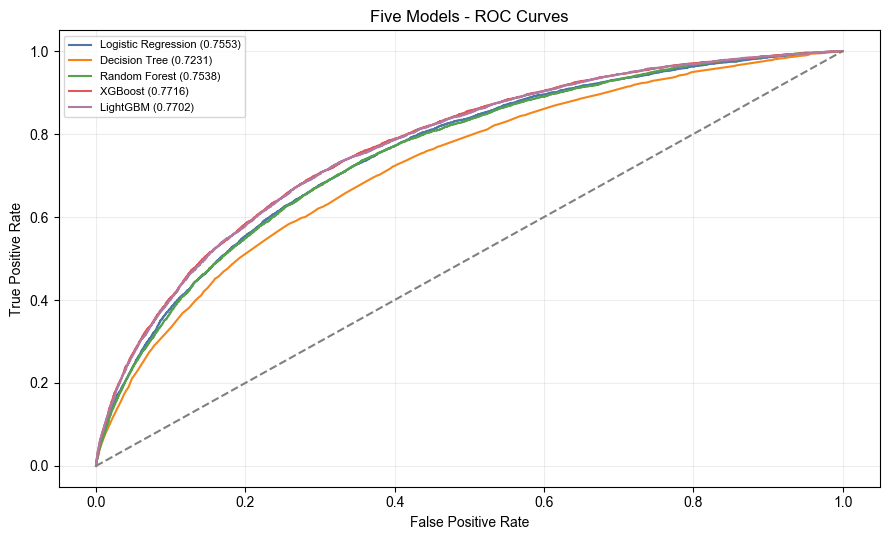

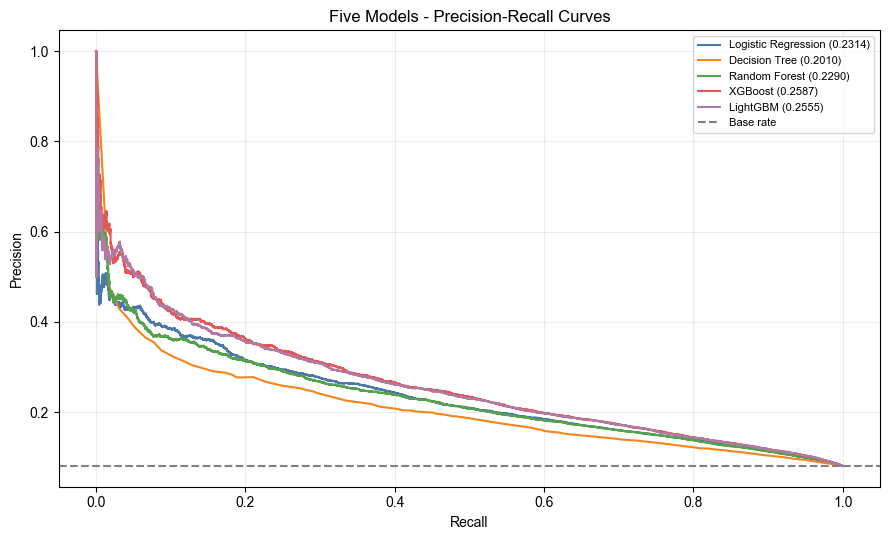

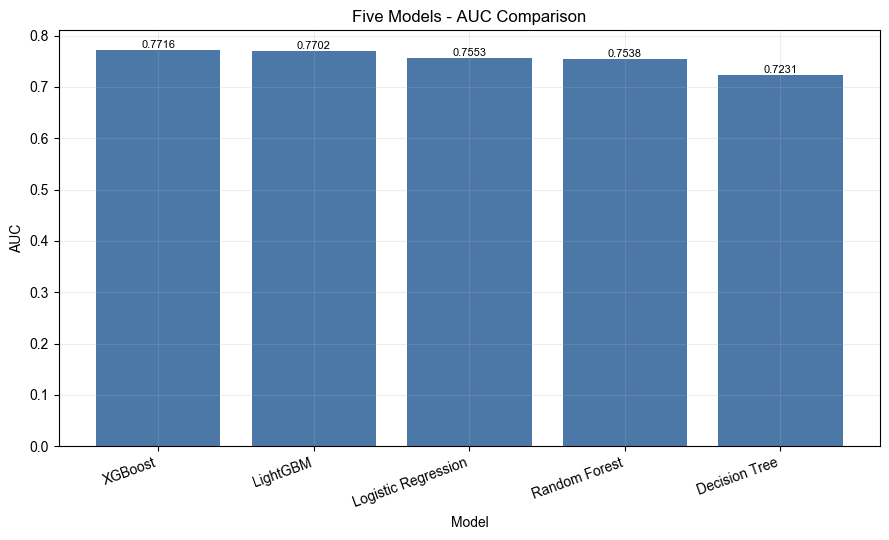

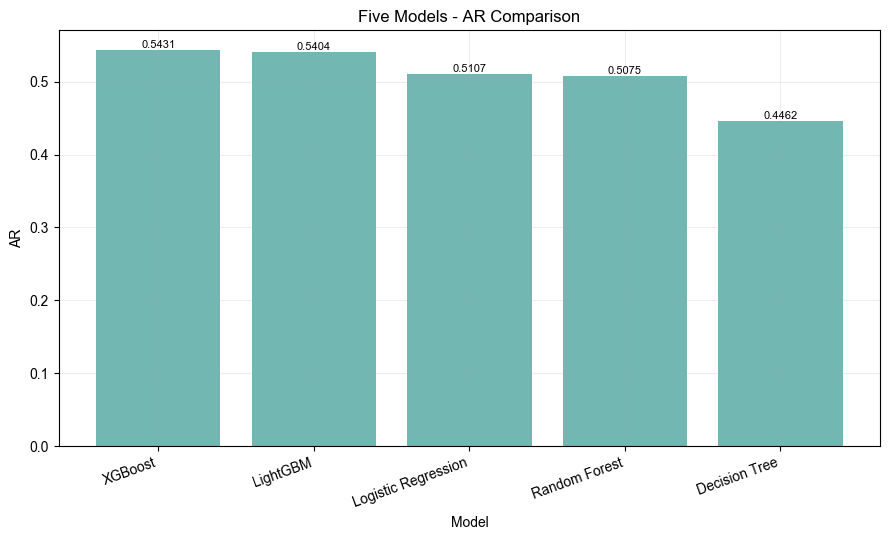

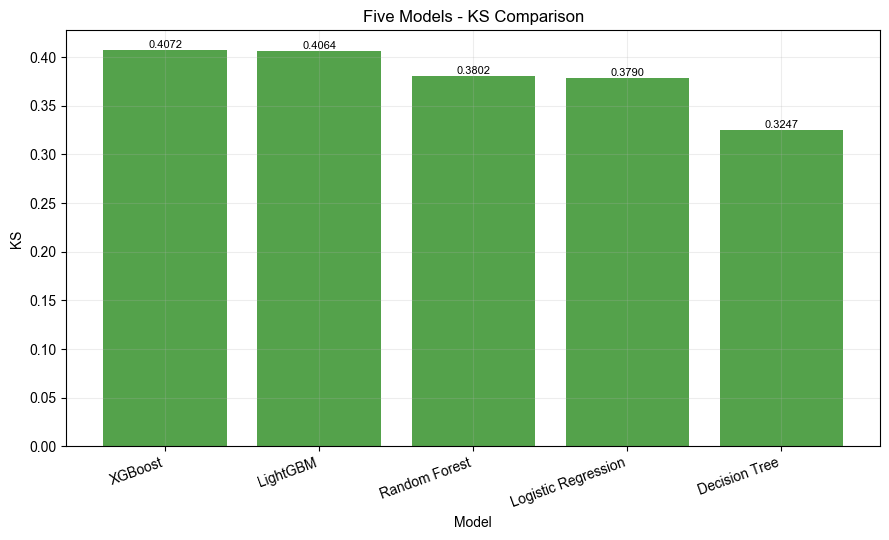

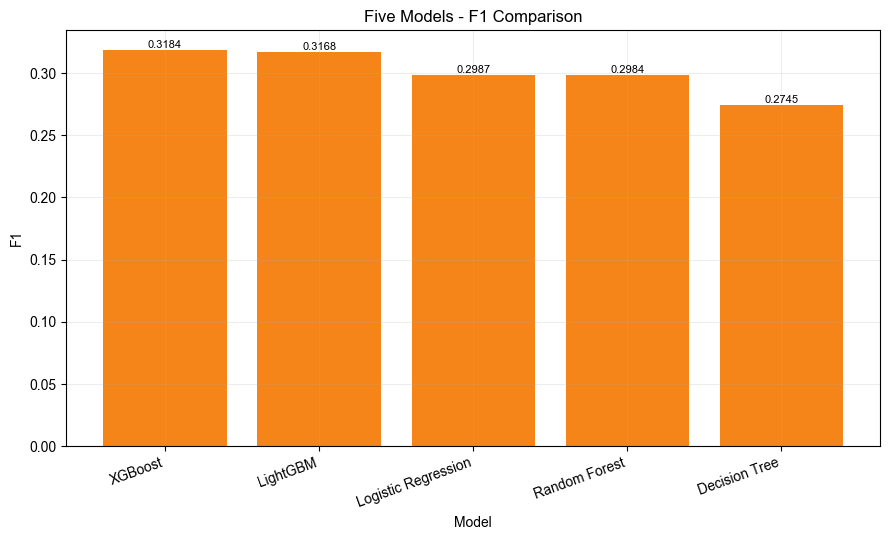

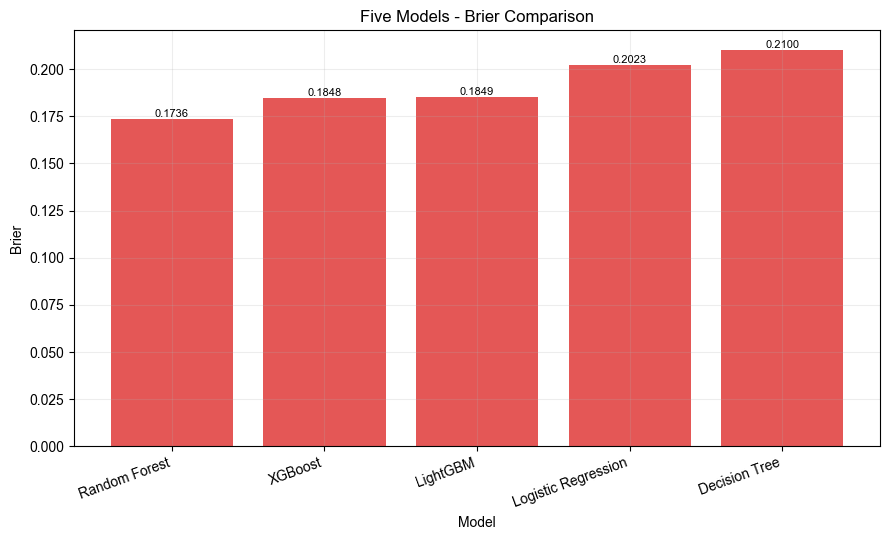

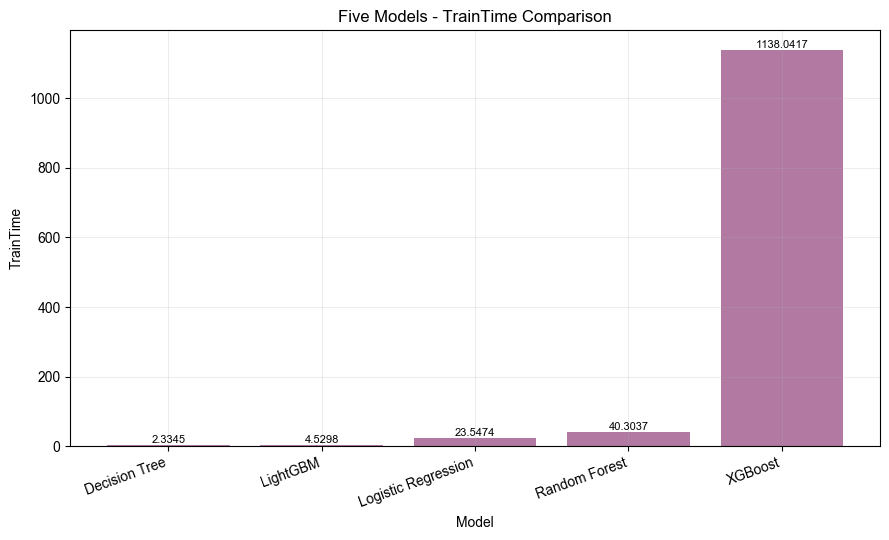

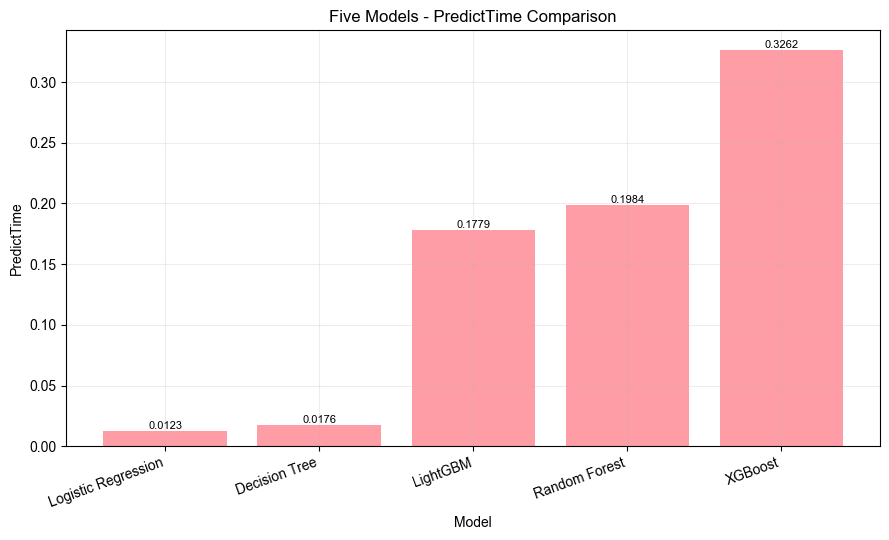

In [24]:
model_colors = {
    "Logistic Regression": "#4C78A8",
    "Decision Tree": "#F58518",
    "Random Forest": "#54A24B",
    "XGBoost": "#E45756",
    "LightGBM": "#B279A2",
}

plt.figure()
for model_name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[model_name]["test"])
    auc = roc_auc_score(y_test, probabilities[model_name]["test"])
    plt.plot(fpr, tpr, label=f"{model_name} ({auc:.4f})", color=model_colors[model_name])
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Five Models - ROC Curves")
plt.legend(fontsize=8)
save_figure("comparison_roc_curves.png", show=True)

plt.figure()
for model_name in models:
    precision, recall, _ = precision_recall_curve(y_test, probabilities[model_name]["test"])
    pr_auc = average_precision_score(y_test, probabilities[model_name]["test"])
    plt.plot(recall, precision, label=f"{model_name} ({pr_auc:.4f})", color=model_colors[model_name])
plt.axhline(y_test.mean(), linestyle="--", color="gray", label="Base rate")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Five Models - Precision-Recall Curves")
plt.legend(fontsize=8)
save_figure("comparison_pr_curves.png", show=True)


def plot_metric_comparison(frame, metric, ascending=False, color="#4C78A8"):
    '''Save a five-model bar chart for one metric.'''
    ordered = frame.sort_values(metric, ascending=ascending)
    plt.figure(figsize=(9, 5.5))
    plt.bar(ordered["Model"], ordered[metric], color=color)
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.title(f"Five Models - {metric} Comparison")
    plt.xticks(rotation=20, ha="right")
    for index, value in enumerate(ordered[metric]):
        plt.text(index, value, f"{value:.4f}", ha="center", va="bottom", fontsize=8)
    save_figure(f"comparison_{metric.lower().replace('-', '_')}.png", show=True)


for metric, color, ascending in [
    ("AUC", "#4C78A8", False),
    ("AR", "#72B7B2", False),
    ("KS", "#54A24B", False),
    ("F1", "#F58518", False),
    ("Brier", "#E45756", True),
    ("TrainTime", "#B279A2", True),
    ("PredictTime", "#FF9DA6", True),
]:
    plot_metric_comparison(model_metrics, metric, ascending=ascending, color=color)

## 15. Risk-Decile Analysis

Test predictions are divided into ten bands from lowest to highest risk. The analysis focuses on bad-rate monotonicity, high-risk lift, and cumulative bad-applicant capture starting from the highest-risk band.


In [25]:
def build_decile_table(model_name, y_true, y_prob) -> pd.DataFrame:
    '''Build a risk-decile table from low to high risk.'''
    work = pd.DataFrame({"actual": np.asarray(y_true), "probability": np.asarray(y_prob)})
    work["RiskDecile"] = pd.qcut(
        work["probability"].rank(method="first"),
        10,
        labels=list(range(1, 11)),
    ).astype(int)
    summary = work.groupby("RiskDecile", observed=True).agg(
        SampleCount=("actual", "size"),
        BadCount=("actual", "sum"),
        ActualBadRate=("actual", "mean"),
        MeanPredictedPD=("probability", "mean"),
    ).reset_index()
    summary["SampleShare"] = summary["SampleCount"] / len(work)
    summary["Lift"] = summary["ActualBadRate"] / work["actual"].mean()
    high_to_low_bad = summary.sort_values("RiskDecile", ascending=False)["BadCount"].cumsum()
    cumulative_map = dict(zip(
        summary.sort_values("RiskDecile", ascending=False)["RiskDecile"],
        high_to_low_bad / summary["BadCount"].sum(),
    ))
    summary["CumulativeBadCaptureHighToLow"] = summary["RiskDecile"].map(cumulative_map)
    summary["RiskLevel"] = pd.cut(
        summary["RiskDecile"],
        bins=[0, 3, 7, 10],
        labels=["Low", "Medium", "High"],
    ).astype(str)
    summary.insert(0, "Model", model_name)
    return summary


def plot_decile_outputs(model_name, table, show=False):
    '''Save bad-rate, lift, cumulative-capture, and predicted-versus-actual PD charts.'''
    slug = slugify_model_name(model_name)

    plt.figure()
    plt.plot(table["RiskDecile"], table["ActualBadRate"], marker="o", color="#E45756")
    plt.xlabel("Risk Decile (1=Low, 10=High)")
    plt.ylabel("Actual Bad Rate")
    plt.title(f"{model_name} - Decile Bad Rate")
    save_figure(f"{slug}_decile_bad_rate.png", show=show)

    plt.figure()
    plt.bar(table["RiskDecile"], table["Lift"], color="#54A24B")
    plt.axhline(1.0, linestyle="--", color="gray")
    plt.xlabel("Risk Decile (1=Low, 10=High)")
    plt.ylabel("Lift")
    plt.title(f"{model_name} - Decile Lift")
    save_figure(f"{slug}_decile_lift.png", show=show)

    descending = table.sort_values("RiskDecile", ascending=False).copy()
    descending["CumulativePopulation"] = descending["SampleShare"].cumsum()
    descending["CumulativeBadCapture"] = descending["BadCount"].cumsum() / descending["BadCount"].sum()
    plt.figure()
    plt.plot(descending["CumulativePopulation"], descending["CumulativeBadCapture"], marker="o")
    plt.plot([0, 1], [0, 1], "--", color="gray")
    plt.xlabel("Cumulative Population from Highest Risk")
    plt.ylabel("Cumulative Bad Capture")
    plt.title(f"{model_name} - Cumulative Bad Capture")
    save_figure(f"{slug}_cumulative_bad_capture.png", show=show)

    plt.figure()
    plt.plot(table["RiskDecile"], table["MeanPredictedPD"], marker="o", label="Mean Predicted PD")
    plt.plot(table["RiskDecile"], table["ActualBadRate"], marker="s", label="Actual Bad Rate")
    plt.xlabel("Risk Decile (1=Low, 10=High)")
    plt.ylabel("Rate")
    plt.title(f"{model_name} - Predicted PD vs Actual Bad Rate")
    plt.legend()
    save_figure(f"{slug}_decile_calibration.png", show=show)

,Model,AdjacentMonotonicIncreaseRate,TopDecileBadCapture,TopDecileLift
3,XGBoost,1.0,0.3513,3.5122
4,LightGBM,1.0,0.3501,3.5001
0,Logistic Regression,1.0,0.3273,3.2725
2,Random Forest,1.0,0.3215,3.2141
1,Decision Tree,1.0,0.2979,2.9785


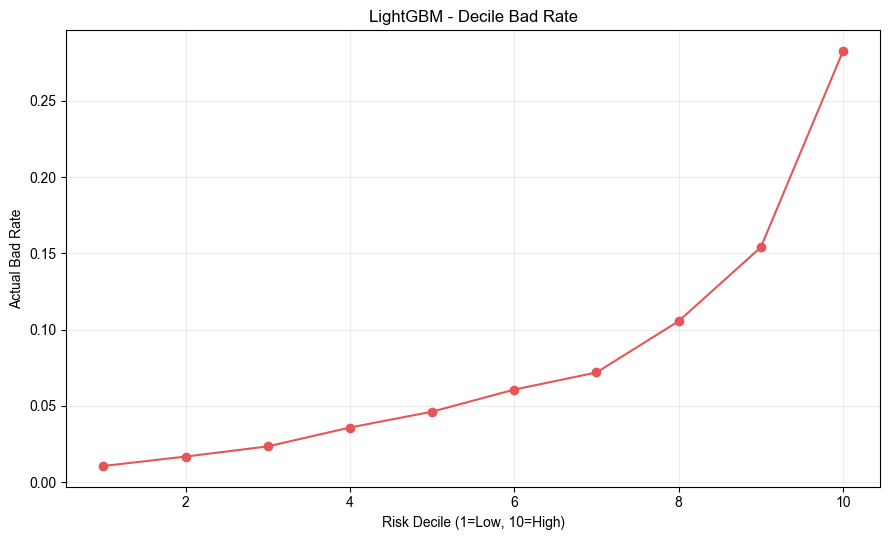

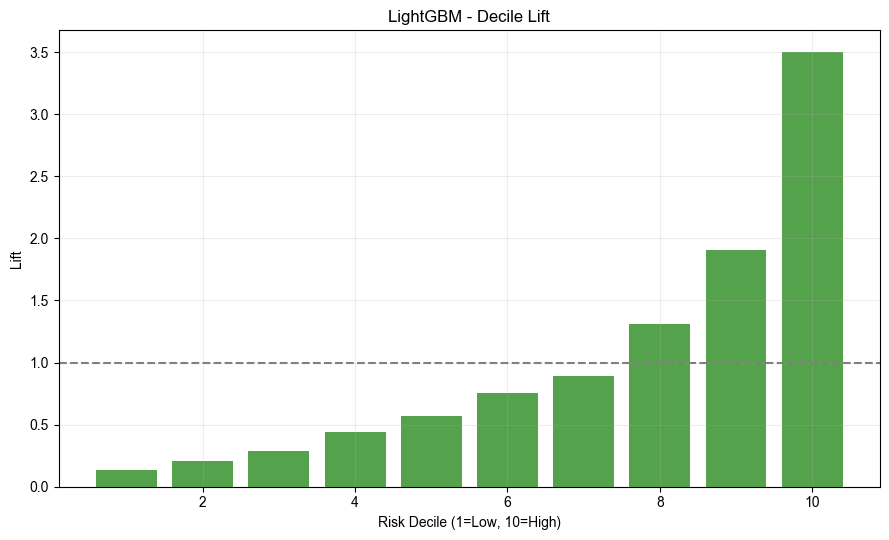

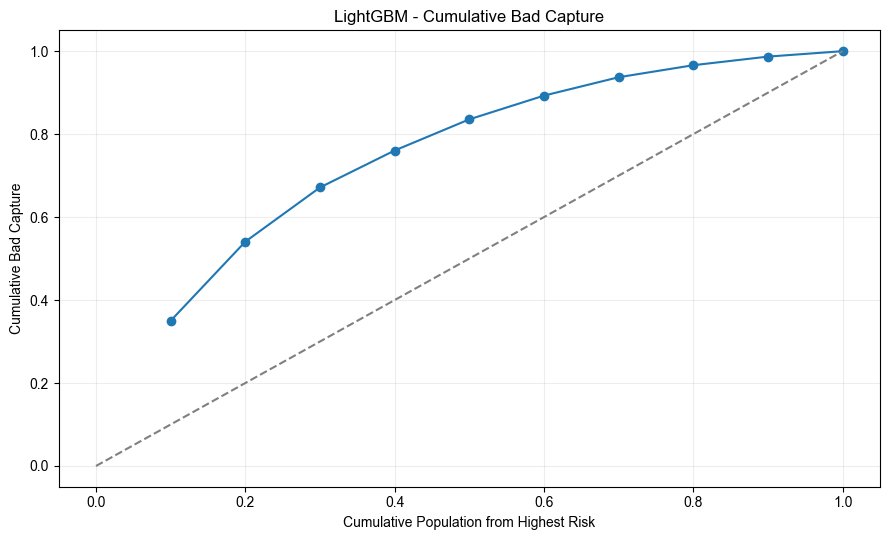

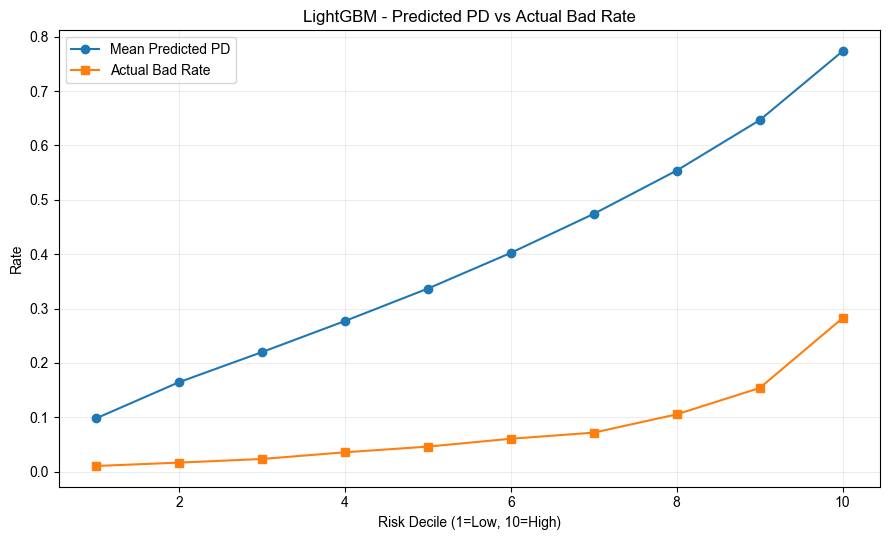

In [26]:
decile_tables = []
decile_quality_rows = []
for model_name in models:
    table = build_decile_table(model_name, y_test, probabilities[model_name]["test"])
    decile_tables.append(table)
    adjacent_increase_rate = float((np.diff(table["ActualBadRate"]) >= 0).mean())
    top_decile_capture = float(
        table.loc[table["RiskDecile"] == 10, "BadCount"].iloc[0] / table["BadCount"].sum()
    )
    decile_quality_rows.append({
        "Model": model_name,
        "AdjacentMonotonicIncreaseRate": adjacent_increase_rate,
        "TopDecileBadCapture": top_decile_capture,
        "TopDecileLift": float(table.loc[table["RiskDecile"] == 10, "Lift"].iloc[0]),
    })
    plot_decile_outputs(model_name, table, show=False)

decile_analysis = pd.concat(decile_tables, ignore_index=True)
decile_quality = pd.DataFrame(decile_quality_rows).sort_values(
    ["AdjacentMonotonicIncreaseRate", "TopDecileBadCapture"], ascending=False
)
decile_analysis.to_csv(OUTPUT_DIR / "decile_analysis.csv", index=False)
decile_quality.to_csv(OUTPUT_DIR / "decile_quality_summary.csv", index=False)
display(decile_quality.round(4))

best_validation_model = overfit_comparison.sort_values("ValidationAUC", ascending=False)["Model"].iloc[0]
plot_decile_outputs(
    best_validation_model,
    decile_analysis[decile_analysis["Model"] == best_validation_model],
    show=True,
)

## 16. Probability Calibration for the Best Two Models

The best two models are selected strictly by validation AUC. The validation set is split again: one half fits Platt and Isotonic calibration, while the other half selects the calibration method and threshold. The test set is used only for final evaluation.


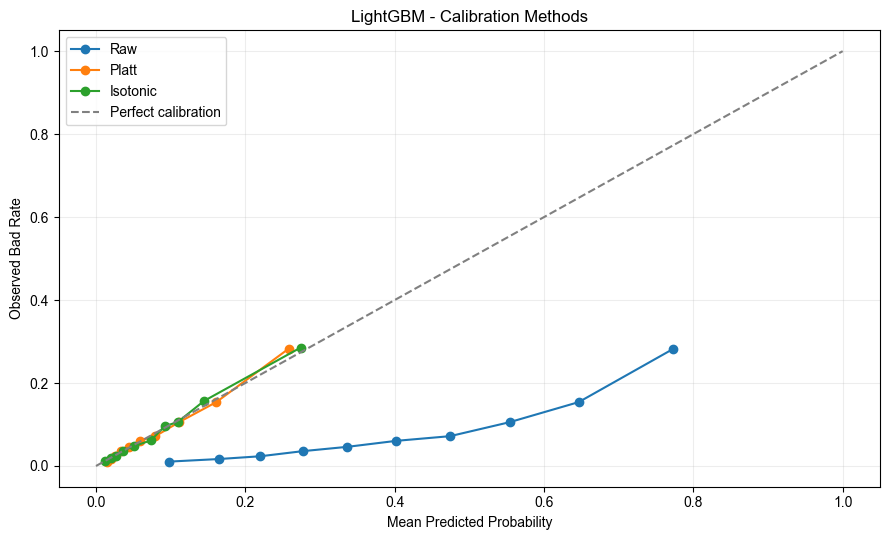

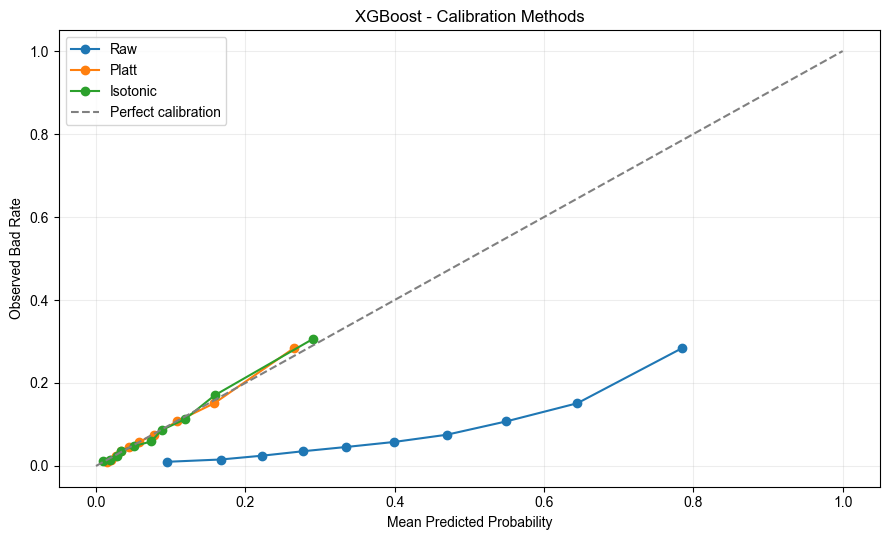

,Model,Calibration,Threshold,ValidationAUC,ValidationBrier,ValidationLogLoss,AUC,AR,KS,PR-AUC,F1,Brier,LogLoss
0,LightGBM,Raw,0.6697,0.7724,0.1868,0.5510,0.7702,0.5404,0.4064,0.2555,0.3173,0.1849,0.5467
1,LightGBM,Platt,0.1753,0.7724,0.0670,0.2422,0.7702,0.5404,0.4064,0.2555,0.3173,0.0674,0.2433
2,LightGBM,Isotonic,0.1917,0.7720,0.0667,0.2426,0.7697,0.5394,0.4063,0.2442,0.3115,0.0673,0.2442
3,XGBoost,Raw,0.6960,0.7709,0.1869,0.5526,0.7716,0.5431,0.4072,0.2587,0.3167,0.1848,0.5478
4,XGBoost,Platt,0.1912,0.7709,0.0670,0.2423,0.7716,0.5431,0.4072,0.2587,0.3167,0.0672,0.2427
5,XGBoost,Isotonic,0.1667,0.7703,0.0667,0.2421,0.7713,0.5426,0.4058,0.2489,0.3183,0.0672,0.2433


,Model,SelectedCalibrationByValidationBrier,ValidationBrier,TestBrier
0,LightGBM,Isotonic,0.0667,0.0673
1,XGBoost,Isotonic,0.0667,0.0672


In [27]:
top_two_models = (
    overfit_comparison.sort_values("ValidationAUC", ascending=False)
    .head(2)["Model"]
    .tolist()
)

validation_positions = np.arange(len(y_valid))
calibration_fit_positions, calibration_select_positions = train_test_split(
    validation_positions,
    test_size=0.5,
    stratify=np.asarray(y_valid),
    random_state=RANDOM_STATE,
)

calibration_rows = []
calibrated_probabilities = {}
selected_calibration_rows = []

for model_name in top_two_models:
    valid_probability = probabilities[model_name]["validation"]
    test_probability = probabilities[model_name]["test"]

    platt = LogisticRegression(random_state=RANDOM_STATE, max_iter=1_000)
    platt.fit(
        valid_probability[calibration_fit_positions].reshape(-1, 1),
        np.asarray(y_valid)[calibration_fit_positions],
    )
    isotonic = IsotonicRegression(out_of_bounds="clip")
    isotonic.fit(
        valid_probability[calibration_fit_positions],
        np.asarray(y_valid)[calibration_fit_positions],
    )

    transformations = {
        "Raw": lambda values: np.asarray(values),
        "Platt": lambda values, fitted=platt: fitted.predict_proba(np.asarray(values).reshape(-1, 1))[:, 1],
        "Isotonic": lambda values, fitted=isotonic: fitted.predict(np.asarray(values)),
    }
    calibrated_probabilities[model_name] = {}
    model_selection_candidates = []

    for method, transform in transformations.items():
        valid_calibrated = np.clip(transform(valid_probability), 1e-7, 1 - 1e-7)
        test_calibrated = np.clip(transform(test_probability), 1e-7, 1 - 1e-7)
        calibrated_probabilities[model_name][method] = test_calibrated

        selection_y = np.asarray(y_valid)[calibration_select_positions]
        selection_probability = valid_calibrated[calibration_select_positions]
        selected_threshold = select_thresholds(selection_y, selection_probability)["max_f1"]
        validation_metrics = evaluate_model(
            model_name,
            selection_y,
            selection_probability,
            selected_threshold,
        )
        test_metrics = evaluate_model(model_name, y_test, test_calibrated, selected_threshold)

        row = {
            "Model": model_name,
            "Calibration": method,
            "Threshold": selected_threshold,
            "ValidationAUC": validation_metrics["AUC"],
            "ValidationBrier": validation_metrics["Brier"],
            "ValidationLogLoss": validation_metrics["LogLoss"],
            "AUC": test_metrics["AUC"],
            "AR": test_metrics["AR"],
            "KS": test_metrics["KS"],
            "PR-AUC": test_metrics["PR-AUC"],
            "F1": test_metrics["F1"],
            "Brier": test_metrics["Brier"],
            "LogLoss": test_metrics["LogLoss"],
        }
        calibration_rows.append(row)
        model_selection_candidates.append(row)

    selected_row = min(model_selection_candidates, key=lambda item: item["ValidationBrier"])
    selected_calibration_rows.append({
        "Model": model_name,
        "SelectedCalibrationByValidationBrier": selected_row["Calibration"],
        "ValidationBrier": selected_row["ValidationBrier"],
        "TestBrier": selected_row["Brier"],
    })

    plt.figure()
    for method in transformations:
        observed, predicted = calibration_curve(
            y_test,
            calibrated_probabilities[model_name][method],
            n_bins=10,
            strategy="quantile",
        )
        plt.plot(predicted, observed, marker="o", label=method)
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Bad Rate")
    plt.title(f"{model_name} - Calibration Methods")
    plt.legend()
    save_figure(f"{slugify_model_name(model_name)}_calibration_methods.png", show=True)

calibration_results = pd.DataFrame(calibration_rows)
selected_calibration = pd.DataFrame(selected_calibration_rows)
calibration_results.to_csv(OUTPUT_DIR / "calibration_results.csv", index=False)
selected_calibration.to_csv(OUTPUT_DIR / "selected_calibration_methods.csv", index=False)
display(calibration_results.round(4))
display(selected_calibration.round(4))

## 17. Automated English Analysis Report

Every number in the report is read from the actual results generated in this notebook. No model scores are preset or invented.


In [28]:
def dataframe_to_markdown(frame: pd.DataFrame, float_digits=4) -> str:
    """Generate a Markdown table without requiring tabulate."""
    formatted = frame.copy()
    for column in formatted.columns:
        if pd.api.types.is_float_dtype(formatted[column]):
            formatted[column] = formatted[column].map(lambda value: f"{value:.{float_digits}f}")
    headers = [str(column) for column in formatted.columns]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join(["---"] * len(headers)) + " |",
    ]
    for row in formatted.astype(str).itertuples(index=False, name=None):
        lines.append("| " + " | ".join(row) + " |")
    return "\n".join(lines)


result_report_table = model_metrics[[
    "Model", "AUC", "AR", "KS", "PR-AUC", "Precision", "Recall", "F1",
    "Brier", "LogLoss", "TrainTime", "PredictTime",
]].copy()

best_auc_row = model_metrics.loc[model_metrics["AUC"].idxmax()]
best_brier_row = model_metrics.loc[model_metrics["Brier"].idxmin()]
fastest_row = model_metrics.loc[model_metrics["TrainTime"].idxmin()]
best_auc = float(best_auc_row["AUC"])
balanced_candidates = model_metrics[model_metrics["AUC"] >= best_auc - 0.01]
balanced_row = balanced_candidates.loc[balanced_candidates["TrainTime"].idxmin()]

decision_tree_gap = float(
    overfit_comparison.loc[overfit_comparison["Model"] == "Decision Tree", "TrainValidationGap"].iloc[0]
)
random_forest_gap = float(
    overfit_comparison.loc[overfit_comparison["Model"] == "Random Forest", "TrainValidationGap"].iloc[0]
)

model_tradeoffs = pd.DataFrame([
    {"Model": "Logistic Regression", "PrimaryStrength": "Interpretable, fast, and easy to deploy", "PrimaryLimitation": "Limited linear and interaction capacity"},
    {"Model": "Decision Tree", "PrimaryStrength": "Intuitive rules and nonlinear relationships", "PrimaryLimitation": "High variance and prone to overfitting"},
    {"Model": "Random Forest", "PrimaryStrength": "More stable than one tree and captures interactions", "PrimaryLimitation": "Larger model with higher interpretation cost"},
    {"Model": "XGBoost", "PrimaryStrength": "Strong tabular discrimination and regularization", "PrimaryLimitation": "Higher tuning and deployment complexity"},
    {"Model": "LightGBM", "PrimaryStrength": "Strong balance of speed, memory, and performance", "PrimaryLimitation": "Leaf-wise growth requires overfit controls"},
])
model_tradeoffs.to_csv(OUTPUT_DIR / "model_tradeoffs.csv", index=False)

report = f'''# Comparing Five Machine Learning Models for Credit Risk Using Home Credit Data

## 1. Executive Summary

This study uses the Home Credit Default Risk application table to compare Logistic Regression, Decision Tree, Random Forest, XGBoost, and LightGBM under one evaluation framework. The principal metrics are ROC-AUC, AR, KS, PR-AUC, F1, Recall, Brier Score, Log Loss, training time, and prediction time, supplemented by validation-selected thresholds, risk deciles, and probability calibration. On the held-out test set, **{best_auc_row['Model']}** provides the highest AUC (AUC={best_auc_row['AUC']:.4f}, KS={best_auc_row['KS']:.4f}, PR-AUC={best_auc_row['PR-AUC']:.4f}), while **{best_brier_row['Model']}** has the lowest raw-probability Brier Score ({best_brier_row['Brier']:.4f}).

## 2. Data and Prediction Task

- Source: Kaggle Home Credit Default Risk, using `application_train.csv`.
- Observations in this run: {len(df_raw):,}; original columns: {df_raw.shape[1]}.
- `TARGET=1` indicates repayment difficulty; the observed bad-applicant rate is {y.mean():.2%}.
- Cleaning covers the employment-day sentinel, infinite values, entirely missing or constant fields, and training-only high-missingness/high-correlation filtering.
- {len(engineered_features)} interpretable ratio features are added.
- Data is stratified into 60% training, 20% validation, and 20% test; the final test set contains {len(y_test):,} applicants.
- Training-only selection retains {len(selected_columns)} raw/engineered features and produces {X_train_tree.shape[1]} encoded model features.

## 3. Modeling Methods

Logistic Regression provides a linear and interpretable scorecard baseline. Decision Tree learns explicit nonlinear split rules. Random Forest uses bagging to reduce the variance of a single tree. XGBoost applies regularized gradient boosting, while LightGBM uses efficient histogram learning with leaf-wise growth. All five models use the same data split and training-fitted preprocessing to ensure a fair comparison.

## 4. Experimental Design

- Logistic Regression uses GridSearchCV; Decision Tree and Random Forest use RandomizedSearchCV.
- XGBoost and LightGBM use validation AUC with early stopping, and class weights are derived from the training-set good/bad ratio.
- Cross-validation uses {CV_FOLDS} folds and a stratified tuning subset of {len(y_tune):,} training observations; final models use the complete training set.
- Maximum-F1, maximum-Youden, and target-Recall thresholds are selected on validation data. The test set is not used for threshold selection.
- The two strongest models are selected by validation AUC. A validation split then compares Raw, Platt, and Isotonic probabilities.

## 5. Results

{dataframe_to_markdown(result_report_table)}

The Decision Tree train/validation AUC gap is {decision_tree_gap:.4f}; the Random Forest gap is {random_forest_gap:.4f}. These gaps help diagnose overfitting. Complete threshold, feature-importance, calibration, and risk-decile outputs are saved as CSV and PNG files.

## 6. Model Strengths and Limitations

### Logistic Regression
Its strengths are interpretability, fast training, straightforward deployment, and clear regulatory communication. Its limitations are a primarily linear decision boundary and weaker handling of complex interactions, outliers, and multicollinearity. Training-only correlation filtering, scaling, and signed coefficient ranking improve interpretability in this project.

### Decision Tree
Its strengths are transparent rules, no need for scaling, and automatic nonlinear interactions. Its weaknesses are instability and overfitting. The observed train/validation gap of {decision_tree_gap:.4f} should be considered alongside tree depth, leaf count, and test performance.

### Random Forest
Bagging makes it more stable than a single tree and effective for nonlinear relationships. Its disadvantages are larger model size, lower interpretability, and probabilities that often require calibration. The single-tree and forest gaps ({decision_tree_gap:.4f} versus {random_forest_gap:.4f}) show how variance control must still be checked empirically.

### XGBoost
XGBoost is strong on tabular data and provides mature regularization and class-imbalance controls, often producing high AUC, AR, and KS. Its disadvantages are tuning cost and greater deployment complexity. This project controls overfitting with shallow trees and early stopping.

### LightGBM
LightGBM offers strong speed and memory efficiency on large sparse datasets. Leaf-wise growth can overfit, however, and requires careful control of `num_leaves`, depth, leaf size, and regularization. These controls are combined with early stopping here.

## 7. Model Selection Recommendations

1. **Maximum predictive performance:** choose **{best_auc_row['Model']}**, with test AUC={best_auc_row['AUC']:.4f} and KS={best_auc_row['KS']:.4f}.
2. **Interpretability and regulatory acceptance:** choose **Logistic Regression**, retaining coefficient direction and business-feature explanations.
3. **Speed-performance balance:** among models within 0.01 AUC of the best result, choose **{balanced_row['Model']}**, with a recorded training time of {balanced_row['TrainTime']:.2f} seconds.

A production choice should not rely on AUC alone. Calibration, stability, reject strategy, interpretability, operational cost, and deployment constraints must also be considered. The fastest fitted model in this experiment is **{fastest_row['Model']}**.

## 8. Limitations

- The dataset comes from a historical Kaggle competition, and `TARGET` is not a publicly documented regulatory default definition.
- The application table lacks a clear natural time index, so strict out-of-time validation is not possible.
- Kaggle does not publish labels for its official test set; this study therefore reserves a test split from the training table.
- Features reflect Home Credit's specific business context, and generalization across lenders, regions, and periods requires revalidation.
- Uncalibrated model scores should not be interpreted directly as real loan probability of default.
- The project does not include real LGD, EAD, funding cost, or revenue data, so strategy simulations are not profit estimates.
- This first version does not aggregate `bureau`, `previous_application`, or `installments_payments`; each table should be added separately and measured for incremental value and cost.

## 9. Conclusion

In this experiment, **{best_auc_row['Model']}** provides the strongest discrimination, **{best_brier_row['Model']}** has the lowest raw-probability error, and Logistic Regression is the easiest to interpret. Whether the complex-model gain is worthwhile depends on its AUC/KS improvement over Logistic Regression, calibration benefit, stability, and computational cost. Future work can add credit-history, prior-application, and repayment-detail tables, implement out-of-time stability testing, add sampled SHAP analysis, and evaluate economic value using LGD and EAD.
'''

report_path = OUTPUT_DIR / "model_comparison_report.md"
report_path.write_text(report, encoding="utf-8")
display(Markdown(report))
print(f"English report saved: {report_path}")


# Comparing Five Machine Learning Models for Credit Risk Using Home Credit Data

## 1. Executive Summary

This study uses the Home Credit Default Risk application table to compare Logistic Regression, Decision Tree, Random Forest, XGBoost, and LightGBM under one evaluation framework. On the held-out test set, **XGBoost** provides the highest AUC (AUC=0.7716, KS=0.4072, PR-AUC=0.2587), while **Random Forest** has the lowest raw-probability Brier Score (0.1736).

## 2. Data and Prediction Task

- Source: Kaggle Home Credit Default Risk, using `application_train.csv`.
- Observations: 307,511; original columns: 122.
- `TARGET=1` indicates repayment difficulty; the bad-applicant rate is 8.07%.
- Data is split 60%/20%/20% into training, validation, and test sets.
- Training-only selection retains 108 raw/engineered features and produces 232 encoded features.
- Seven interpretable business ratios are added, with leakage-safe imputation and encoding fitted on training data only.

## 3. Modeling Methods

Logistic Regression provides a linear and interpretable baseline. Decision Tree learns explicit nonlinear split rules. Random Forest uses bagging to reduce variance. XGBoost applies regularized gradient boosting, while LightGBM combines histogram learning with leaf-wise growth. All models share the same split and training-fitted preprocessing.

## 4. Experimental Design

- Logistic Regression uses GridSearchCV; Decision Tree and Random Forest use RandomizedSearchCV.
- XGBoost and LightGBM use validation AUC and early stopping.
- Cross-validation uses 5 folds with a 60,000-row stratified tuning subset.
- Thresholds and calibration methods are selected on validation data only.
- The test set is used only for final model evaluation.

## 5. Results

| Model | AUC | AR | KS | PR-AUC | Precision | Recall | F1 | Brier | LogLoss | TrainTime | PredictTime |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| XGBoost | 0.7716 | 0.5431 | 0.4072 | 0.2587 | 0.2584 | 0.4147 | 0.3184 | 0.1848 | 0.5478 | 1138.0417 | 0.3262 |
| LightGBM | 0.7702 | 0.5404 | 0.4064 | 0.2555 | 0.2570 | 0.4127 | 0.3168 | 0.1849 | 0.5467 | 4.5298 | 0.1779 |
| Logistic Regression | 0.7553 | 0.5107 | 0.3790 | 0.2314 | 0.2296 | 0.4272 | 0.2987 | 0.2023 | 0.5914 | 23.5474 | 0.0123 |
| Random Forest | 0.7538 | 0.5075 | 0.3802 | 0.2290 | 0.2395 | 0.3960 | 0.2984 | 0.1736 | 0.5295 | 40.3037 | 0.1984 |
| Decision Tree | 0.7231 | 0.4462 | 0.3247 | 0.2010 | 0.2037 | 0.4205 | 0.2745 | 0.2100 | 0.6058 | 2.3345 | 0.0176 |

The Decision Tree train/validation AUC gap is 0.0206; the Random Forest gap is 0.1039. Complete threshold, feature-importance, calibration, and risk-decile results are available in the accompanying CSV and PNG files.

## 6. Model Strengths and Limitations

### Logistic Regression
Interpretable, fast, easy to deploy, and appropriate as a regulated credit-scoring baseline. Its linear structure is less effective for complex nonlinear relationships and interactions.

### Decision Tree
Provides transparent nonlinear rules without scaling, but has high variance and can overfit quickly as depth increases.

### Random Forest
More stable than a single tree and effective for nonlinear interactions. It is larger, less interpretable, and its probabilities may require calibration.

### XGBoost
Provides strong tabular discrimination and mature regularization. Its principal costs are tuning time, parameter complexity, and more demanding deployment and explanation.

### LightGBM
Offers an excellent speed-memory-performance balance on large sparse data. Leaf-wise growth requires careful depth, leaf-size, and regularization controls.

## 7. Model Selection Recommendations

1. **Maximum predictive performance:** choose **XGBoost** with test AUC=0.7716 and KS=0.4072.
2. **Interpretability and regulatory acceptance:** choose **Logistic Regression** and retain coefficient direction and business-variable explanations.
3. **Speed-performance balance:** choose **LightGBM** among models within 0.01 AUC of the best result; its recorded training time is 4.53 seconds.

The fastest fitted model is **Decision Tree**. A production decision should also consider calibration, stability, reject strategy, interpretability, operational cost, and deployment constraints.

## 8. Limitations

- This is a historical Kaggle dataset, and `TARGET` is not a public regulatory default definition.
- There is no clear natural time index for strict out-of-time validation.
- Kaggle does not publish labels for the official test set, so this study reserves an internal test split.
- The features reflect Home Credit's business context and require revalidation across lenders, regions, and periods.
- Uncalibrated scores should not be interpreted directly as real probability of default.
- Real LGD, EAD, funding cost, revenue, and profitability are not included.
- `bureau`, `previous_application`, and `installments_payments` are not aggregated in this first version.

## 9. Conclusion

**XGBoost** provides the strongest discrimination, **Random Forest** has the lowest raw-probability error, and Logistic Regression remains the easiest to explain. LightGBM is the strongest speed-performance compromise. The value of the complex-model gain should be judged against calibration, stability, interpretability, and computational cost.


English report saved: outputs/model_comparison_report.md


## 18. Staged Entry Point for Historical Tables

The current data directory contains only the application table. The notebook records the availability of three future history tables. Each table should be aggregated by `SK_ID_CURR`, left-joined separately, and evaluated by changes in feature count, AUC, AR, KS, training time, and feature importance.


In [29]:
extension_files = ["bureau.csv", "previous_application.csv", "installments_payments.csv"]
extension_status = pd.DataFrame({
    "file": extension_files,
    "available": [(DATA_DIR / file_name).exists() for file_name in extension_files],
    "planned_join_key": ID_COL,
    "status": [
        "ready_for_next_stage" if (DATA_DIR / file_name).exists() else "not_available_in_current_data_dir"
        for file_name in extension_files
    ],
})
extension_status.to_csv(OUTPUT_DIR / "extension_data_status.csv", index=False)
display(extension_status)

,file,available,planned_join_key,status
0,bureau.csv,False,SK_ID_CURR,not_available_in_current_data_dir
1,previous_application.csv,False,SK_ID_CURR,not_available_in_current_data_dir
2,installments_payments.csv,False,SK_ID_CURR,not_available_in_current_data_dir


## 19. Final Acceptance Check

The automated check covers all five models, core metrics, predicted probabilities, output tables, figures, and the English report. `ACCEPTANCE_STATUS=PASS` is printed only when every check succeeds.


In [30]:
required_output_files = [
    OUTPUT_DIR / "model_metrics.csv",
    OUTPUT_DIR / "best_parameters.csv",
    OUTPUT_DIR / "decile_analysis.csv",
    OUTPUT_DIR / "calibration_results.csv",
    OUTPUT_DIR / "model_comparison_report.md",
    OUTPUT_DIR / "feature_importance_summary.csv",
    OUTPUT_DIR / "threshold_analysis.csv",
]

acceptance_checks = {
    "five_models_trained": len(models) == 5,
    "five_models_in_metrics": model_metrics["Model"].nunique() == 5,
    "all_core_metrics_finite": np.isfinite(
        model_metrics[["AUC", "AR", "KS", "PR-AUC", "F1", "Recall", "Brier"]].to_numpy()
    ).all(),
    "all_test_probabilities_finite": all(
        len(probabilities[name]["test"]) == len(y_test)
        and np.isfinite(probabilities[name]["test"]).all()
        for name in models
    ),
    "no_target_or_id_in_features": TARGET_COL not in selected_columns and ID_COL not in selected_columns,
    "required_output_files_exist": all(path.exists() for path in required_output_files),
    "calibration_completed_for_two_models": calibration_results["Model"].nunique() == 2,
    "all_models_have_deciles": decile_analysis["Model"].nunique() == 5,
    "sufficient_figures_generated": len(list(FIGURE_DIR.glob("*.png"))) >= 50,
    "five_model_artifacts_saved": len(list(MODEL_DIR.glob("*.joblib"))) >= 7,
}

acceptance_frame = pd.DataFrame({
    "check": acceptance_checks.keys(),
    "passed": acceptance_checks.values(),
})
acceptance_frame.to_csv(OUTPUT_DIR / "acceptance_check.csv", index=False)
display(acceptance_frame)

failed_checks = acceptance_frame.loc[~acceptance_frame["passed"], "check"].tolist()
if failed_checks:
    raise AssertionError(f"Acceptance checks failed: {failed_checks}")

print("ACCEPTANCE_STATUS=PASS")
print(f"Model count: {len(models)}")
print(f"Figure count: {len(list(FIGURE_DIR.glob('*.png')))}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

,check,passed
0,five_models_trained,True
1,five_models_in_metrics,True
2,all_core_metrics_finite,True
3,all_test_probabilities_finite,True
4,no_target_or_id_in_features,True
5,required_output_files_exist,True
6,calibration_completed_for_two_models,True
7,all_models_have_deciles,True
8,sufficient_figures_generated,True
9,five_model_artifacts_saved,True


ACCEPTANCE_STATUS=PASS
Model count: 5
Figure count: 70
Output directory: /Users/ganlu/Desktop/lending-club-master/outputs
